# Sentiment Analysis Optimization using Bio Inspired Algorithm
## Dataset provided : https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences
3 TSV Files 
### Members 
- Aniruddha Panchal
- kinjal Surve
- Tanuj Balivada
- Vanshika Chinchkhede

Models experimented :
- KNN 

- RANDOM FOREST 

- DECISION TREE 

- SVM

- GRADIENT B 

- XGRADIENT B 

Algorithms : 
- Particle Swarm Optimization (PSO) – inspired by bird flocking/fish schooling.

- Genetic Algorithm (GA) – based on natural selection and evolution.

- Ant Colony Optimization (ACO) – mimics how ants find shortest paths.

- Bat Algorithm – inspired by echolocation of bats.

- Cuckoo Search – mimics cuckoo birds laying eggs in other nests.

- Firefly Algorithm – based on fireflies attracting each other with light.

- Artificial Bee Colony (ABC) – inspired by honeybee foraging behavior.

## Dataset analysis 

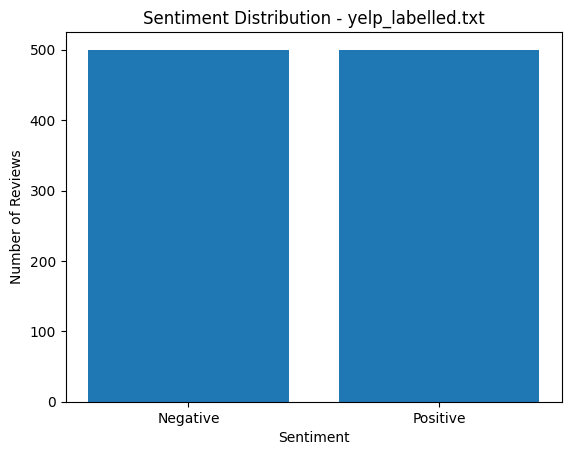

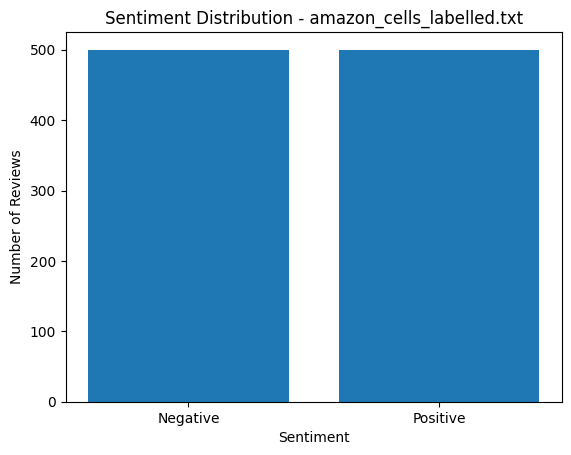

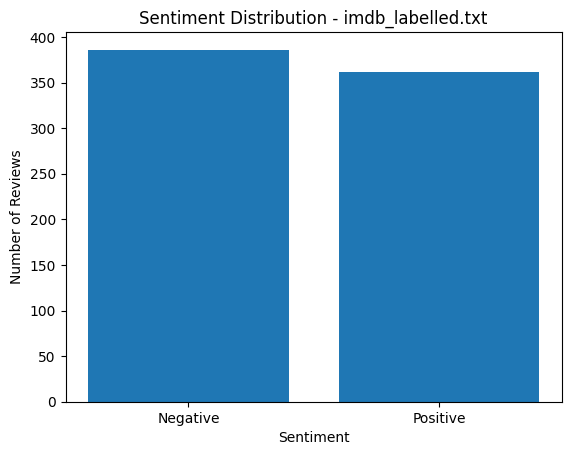

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# List of files
files = ['yelp_labelled.txt', "amazon_cells_labelled.txt", 'imdb_labelled.txt']

# Loop through files
for file in files:
    df = pd.read_csv(file, sep='\t', header=None, names=['text', 'label'])
    counts = df['label'].value_counts()
    
    plt.bar(['Negative', 'Positive'], counts)
    plt.title(f'Sentiment Distribution - {file}')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.show()


 The data in the first two datasets is roughly balanced between positive and negative classes, whereas the third dataset (IMDb ratings) has a slightly higher number of negative samples; however, this minor imbalance can be safely ignored.

# KNN





## KNN (PSO)

In [5]:
import pandas as pd
import numpy as np

# Load all three TSV files
data1 = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
data2 = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
data3 = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])

# Concatenate them
data = pd.concat([data1, data2, data3], ignore_index=True)

# Shuffle (optional but good practice)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples after merging: {len(data)}")
print(data.head())


Total samples after merging: 2748
                                                text  label
0  The attractive set used throughout most of the...      1
1  This was one of the worst films i have ever se...      0
2  The microphone also works well, but (according...      1
3  * Comes with a strong light that you can use t...      1
4  The acting is like watching wooden puppets mov...      0


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)


In [10]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(emb)
    return np.concatenate(all_embeddings, axis=0)


X_train_vect = get_bert_embeddings(X_train)
X_test_vect = get_bert_embeddings(X_test)


In [11]:
from pyswarm import pso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# Objective function for PSO (maximize F1 → minimize 1 - F1)
def objective(features_mask):
    features_mask = np.array(features_mask) > 0.5
    if np.sum(features_mask) == 0:
        return 1.0  # penalty for empty feature set

    X_train_sel = X_train_vect[:, features_mask]
    X_test_sel = X_test_vect[:, features_mask]
    
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    f1 = f1_score(y_test, y_pred)
    return 1 - f1  # PSO minimizes

# PSO parameters
num_features = X_train_vect.shape[1]
lb = [0] * num_features
ub = [1] * num_features

best_features, best_cost = pso(objective, lb, ub, swarmsize=10, maxiter=5)

print("Best F1 Score:", 1 - best_cost)

# Evaluate with best feature mask
best_mask = np.array(best_features) > 0.5
X_train_sel = X_train_vect[:, best_mask]
X_test_sel = X_test_vect[:, best_mask]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Specificity:", specificity)

knn_pso_f1 = f1
knn_pso_specificity = specificity


Stopping search: maximum iterations reached --> 5
Best F1 Score: 0.8551483420593369
Final F1 Score: 0.8551483420593369
Specificity: 0.8283582089552238


## KNN (GA)

In [12]:
import random
import numpy as np
from deap import base, creator, tools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]

creator.create("FitnessMax", base.Fitness, weights=(1.0,))  
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)  
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=num_features)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


In [13]:
def fitness(individual):
    mask = np.array(individual) > 0
    if np.sum(mask) == 0: 
        return 0,
    
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    score = (f1 + specificity) / 2
    return score,
    
toolbox.register("evaluate", fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)


In [14]:
population = toolbox.population(n=20)
NGEN = 10 

for gen in range(NGEN):
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))
    
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.5:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values
    
    for mutant in offspring:
        if random.random() < 0.2:
            toolbox.mutate(mutant)
            del mutant.fitness.values
    
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
    
    population[:] = offspring

best_ind = tools.selBest(population, 1)[0]
print("Best F1+Specificity Score:", fitness(best_ind)[0])
selected_features = np.where(np.array(best_ind) > 0)[0]


Best F1+Specificity Score: 0.8425114657617773


In [15]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_ga_f1 = f1
knn_ga_specificity = specificity


Final F1 Score: 0.8454706927175843
Final Specificity: 0.8395522388059702


## KNN (ANT)

In [16]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]

# ACO parameters
num_ants = 20
num_iterations = 10
pheromone = np.ones(num_features)
alpha = 1  # influence of pheromone
beta = 2   # influence of heuristic (we'll use uniform)
evaporation = 0.1

best_score = 0
best_features = None

for iteration in range(num_iterations):
    all_solutions = []
    all_scores = []

    for ant in range(num_ants):
        # Construct solution probabilistically
        prob = (pheromone ** alpha) * (np.ones(num_features) ** beta)
        prob = prob / np.sum(prob)
        selected = np.random.rand(num_features) < prob  # binary mask
        
        if np.sum(selected) == 0:
            selected[random.randint(0, num_features-1)] = True  # ensure at least 1 feature
        
        X_train_sel = X_train_vect[:, selected]
        X_test_sel = X_test_vect[:, selected]
        
        model = KNeighborsClassifier(n_neighbors=5)
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        
        f1 = f1_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        score = (f1 + specificity) / 2  # combined metric

        all_solutions.append(selected)
        all_scores.append(score)

        # Update best
        if score > best_score:
            best_score = score
            best_features = selected

    # Evaporate pheromones
    pheromone = (1 - evaporation) * pheromone

    # Deposit pheromone proportional to score
    for sol, score in zip(all_solutions, all_scores):
        pheromone += sol * score

    print(f"Iteration {iteration+1}, Best Score so far: {best_score:.4f}")

# Selected feature indices
selected_indices = np.where(best_features)[0]
print("Selected Feature Indices:", selected_indices)


Iteration 1, Best Score so far: 0.6104
Iteration 2, Best Score so far: 0.6104
Iteration 3, Best Score so far: 0.6104
Iteration 4, Best Score so far: 0.6107
Iteration 5, Best Score so far: 0.6107
Iteration 6, Best Score so far: 0.6682
Iteration 7, Best Score so far: 0.6682
Iteration 8, Best Score so far: 0.6682
Iteration 9, Best Score so far: 0.6682
Iteration 10, Best Score so far: 0.6682
Selected Feature Indices: [483 684]


In [17]:
X_train_sel = X_train_vect[:, selected_indices]
X_test_sel = X_test_vect[:, selected_indices]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_ant_f1 = f1
knn_ant_specificity = specificity

Final F1 Score: 0.6909722222222222
Final Specificity: 0.6455223880597015


## KNN (BAT)

In [18]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]

n_bats = 20
n_iterations = 10
A = 0.5 
r = 0.5 
f_min, f_max = 0, 1
alpha, gamma = 0.9, 0.9 

positions = np.random.rand(n_bats, num_features) > 0.5  # binary mask
velocities = np.zeros((n_bats, num_features))
best_score = 0
best_position = None


In [19]:
def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2


In [20]:
for t in range(n_iterations):
    for i in range(n_bats):
        f = f_min + (f_max - f_min) * random.random()
        velocities[i] += (positions[i] ^ (best_position if best_position is not None else positions[i])) * f
        new_pos = positions[i] ^ (velocities[i] > 0.5)  # XOR for binary update

        if random.random() > r: 
            new_pos = positions[i] ^ (np.random.rand(num_features) > 0.5)

        score = fitness(new_pos)
        if score > fitness(positions[i]) and random.random() < A:
            positions[i] = new_pos
            A *= alpha
            r = r * (1 - np.exp(-gamma * t))

        if score > best_score:
            best_score = score
            best_position = new_pos

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_position)[0]


Iteration 1, Best Score so far: 0.8357
Iteration 2, Best Score so far: 0.8357
Iteration 3, Best Score so far: 0.8357
Iteration 4, Best Score so far: 0.8357
Iteration 5, Best Score so far: 0.8357
Iteration 6, Best Score so far: 0.8383
Iteration 7, Best Score so far: 0.8383
Iteration 8, Best Score so far: 0.8383
Iteration 9, Best Score so far: 0.8383
Iteration 10, Best Score so far: 0.8383


In [21]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_bat_f1 = f1
knn_bat_specificity = specificity


Final F1 Score: 0.8445229681978799
Final Specificity: 0.832089552238806


## KNN (CUKOO)

In [22]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

num_features = X_train_vect.shape[1]
n_nests = 20
n_iterations = 10
pa = 0.25 
best_score = 0
best_nest = None

nests = np.random.rand(n_nests, num_features) > 0.5


In [23]:
def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2


In [24]:
import math
import numpy as np
import random

def levy_flight(Lambda=1.5):
    sigma = (math.gamma(1 + Lambda) * math.sin(math.pi * Lambda / 2) /
             (math.gamma((1 + Lambda) / 2) * Lambda * 2 ** ((Lambda - 1) / 2))) ** (1 / Lambda)
    u = np.random.randn(num_features) * sigma
    v = np.random.randn(num_features)
    step = u / np.abs(v) ** (1 / Lambda)
    return step

for t in range(n_iterations):
    for i in range(n_nests):
        step = levy_flight()
        new_nest = nests[i] ^ (np.random.rand(num_features) < np.abs(step))  # XOR update

        if np.sum(new_nest) == 0:
            new_nest[random.randint(0, num_features-1)] = True

        score = fitness(new_nest)

        if score > fitness(nests[i]):
            nests[i] = new_nest

        if score > best_score:
            best_score = score
            best_nest = new_nest

    for i in range(n_nests):
        if random.random() < pa:
            nests[i] = np.random.rand(num_features) > 0.5

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_nest)[0]


Iteration 1, Best Score so far: 0.8284
Iteration 2, Best Score so far: 0.8342
Iteration 3, Best Score so far: 0.8342
Iteration 4, Best Score so far: 0.8342
Iteration 5, Best Score so far: 0.8440
Iteration 6, Best Score so far: 0.8440
Iteration 7, Best Score so far: 0.8440
Iteration 8, Best Score so far: 0.8440
Iteration 9, Best Score so far: 0.8440
Iteration 10, Best Score so far: 0.8440


In [25]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_cukoo_f1 = f1
knn_cukoo_specificity = specificity

Final F1 Score: 0.852112676056338
Final Specificity: 0.835820895522388


## KNN (Firefly Algorithm)

In [26]:
import numpy as np
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]
n_fireflies = 20
n_iterations = 10
alpha = 0.5 
beta0 = 1.0 
gamma = 1.0  
best_score = 0
best_firefly = None

fireflies = np.random.rand(n_fireflies, num_features) > 0.5

def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2

for t in range(n_iterations):
    for i in range(n_fireflies):
        for j in range(n_fireflies):
            if fitness(fireflies[j]) > fitness(fireflies[i]):
                r = np.sum(fireflies[i] != fireflies[j])
                beta = beta0 * np.exp(-gamma * r ** 2)
                move = beta * (fireflies[j] ^ fireflies[i])
                new_pos = fireflies[i] ^ (move > 0.5)
                new_pos ^= (np.random.rand(num_features) < alpha)
                if np.sum(new_pos) == 0:
                    new_pos[random.randint(0, num_features-1)] = True
                fireflies[i] = new_pos
                score = fitness(new_pos)
                if score > best_score:
                    best_score = score
                    best_firefly = new_pos

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_firefly)[0]


Iteration 1, Best Score so far: 0.8368
Iteration 2, Best Score so far: 0.8415
Iteration 3, Best Score so far: 0.8473
Iteration 4, Best Score so far: 0.8473
Iteration 5, Best Score so far: 0.8473
Iteration 6, Best Score so far: 0.8473
Iteration 7, Best Score so far: 0.8561
Iteration 8, Best Score so far: 0.8561
Iteration 9, Best Score so far: 0.8561
Iteration 10, Best Score so far: 0.8561


In [27]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)


y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_firefly_f1 = f1
knn_firefly_specificity = specificity


Final F1 Score: 0.8576512455516014
Final Specificity: 0.8544776119402985


## KNN (ABC)

In [28]:
import numpy as np
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

num_features = X_train_vect.shape[1]
n_bees = 20
n_iterations = 10
limit = 5 
best_score = 0
best_solution = None

foods = np.random.rand(n_bees, num_features) > 0.5
trial = np.zeros(n_bees)  

def fitness(position):
    mask = position.astype(bool)
    if np.sum(mask) == 0:
        return 0
    X_train_sel = X_train_vect[:, mask]
    X_test_sel = X_test_vect[:, mask]
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    return (f1 + specificity) / 2

for t in range(n_iterations):
    for i in range(n_bees):
        k = random.choice([x for x in range(n_bees) if x != i])
        phi = np.random.uniform(-1, 1, num_features)
        new_solution = foods[i] ^ ((foods[i] ^ foods[k]) & (phi > 0))
        if np.sum(new_solution) == 0:
            new_solution[random.randint(0, num_features-1)] = True
        new_score = fitness(new_solution)
        if new_score > fitness(foods[i]):
            foods[i] = new_solution
            trial[i] = 0
        else:
            trial[i] += 1
        if new_score > best_score:
            best_score = new_score
            best_solution = new_solution

    fitness_vals = np.array([fitness(f) for f in foods])
    probs = fitness_vals / (fitness_vals.sum() + 1e-9)
    for i in range(n_bees):
        if random.random() < probs[i]:
            k = random.choice([x for x in range(n_bees) if x != i])
            phi = np.random.uniform(-1, 1, num_features)
            new_solution = foods[i] ^ ((foods[i] ^ foods[k]) & (phi > 0))
            if np.sum(new_solution) == 0:
                new_solution[random.randint(0, num_features-1)] = True
            new_score = fitness(new_solution)
            if new_score > fitness(foods[i]):
                foods[i] = new_solution
                trial[i] = 0
            else:
                trial[i] += 1
            if new_score > best_score:
                best_score = new_score
                best_solution = new_solution

    for i in range(n_bees):
        if trial[i] > limit:
            foods[i] = np.random.rand(num_features) > 0.5
            trial[i] = 0

    print(f"Iteration {t+1}, Best Score so far: {best_score:.4f}")

selected_features = np.where(best_solution)[0]


Iteration 1, Best Score so far: 0.8378
Iteration 2, Best Score so far: 0.8425
Iteration 3, Best Score so far: 0.8425
Iteration 4, Best Score so far: 0.8425
Iteration 5, Best Score so far: 0.8425
Iteration 6, Best Score so far: 0.8524
Iteration 7, Best Score so far: 0.8524
Iteration 8, Best Score so far: 0.8524
Iteration 9, Best Score so far: 0.8524
Iteration 10, Best Score so far: 0.8524


In [29]:
X_train_sel = X_train_vect[:, selected_features]
X_test_sel = X_test_vect[:, selected_features]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_sel, y_train)

y_pred = model.predict(X_test_sel)

f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print("Final F1 Score:", f1)
print("Final Specificity:", specificity)

knn_abc_f1 = f1
knn_abc_specificity = specificity

Final F1 Score: 0.8540925266903915
Final Specificity: 0.8507462686567164


## visualization


In [30]:
algorithms = ["PSO", "GA", "Bat", "ACO", "Firefly", "ABC", "Cuckoo"]
f1_scores = [knn_pso_f1, knn_ga_f1, knn_bat_f1, knn_ant_f1, knn_firefly_f1, knn_abc_f1, knn_cukoo_f1]
specificity = [knn_pso_specificity, knn_ga_specificity, knn_bat_specificity, knn_ant_specificity,
               knn_firefly_specificity, knn_abc_specificity, knn_cukoo_specificity]


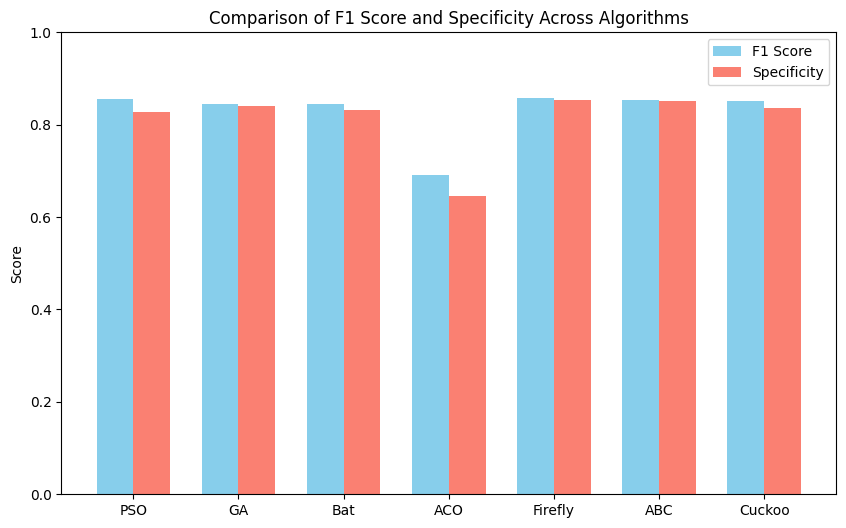

In [31]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(algorithms))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_scores, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, specificity, width, label='Specificity', color='salmon')

plt.xticks(x, algorithms)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('Comparison of F1 Score and Specificity Across Algorithms')
plt.legend()
plt.show()


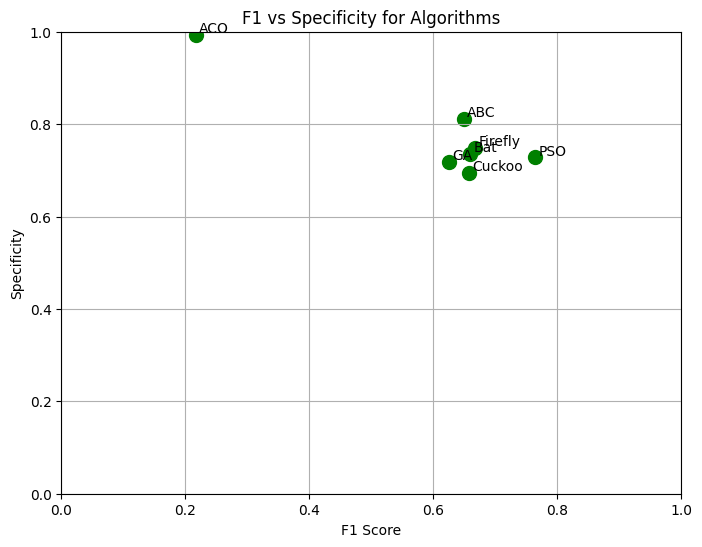

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(f1_scores, specificity, color='green', s=100)

for i, alg in enumerate(algorithms):
    plt.text(f1_scores[i]+0.005, specificity[i]+0.005, alg)

plt.xlabel('F1 Score')
plt.ylabel('Specificity')
plt.title('F1 vs Specificity for Algorithms')
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid(True)
plt.show()


# Random Forest


## Random Forest (PSO)

In [3]:
import pandas as pd
import numpy as np

# Load all three TSV files
data1 = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
data2 = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
data3 = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])

# Concatenate them
data = pd.concat([data1, data2, data3], ignore_index=True)

# Shuffle (optional but good practice)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples after merging: {len(data)}")
print(data.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)
from transformers import BertTokenizer, BertModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

def get_bert_embeddings(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(emb)
    return np.concatenate(all_embeddings, axis=0)

# Run embedding extraction
X_train_vect = get_bert_embeddings(X_train)
X_test_vect = get_bert_embeddings(X_test)


Total samples after merging: 2748
                                                text  label
0  The attractive set used throughout most of the...      1
1  This was one of the worst films i have ever se...      0
2  The microphone also works well, but (according...      1
3  * Comes with a strong light that you can use t...      1
4  The acting is like watching wooden puppets mov...      0


c:\Users\ANIRUDDUHA\anaconda3\envs\tech\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [37]:
def rf_objective(solution):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    min_samples_split = int(solution[2])
    min_samples_leaf = int(solution[3])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    # ✅ Use BERT embeddings
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_pso_f1, rf_pso_specificity
    rf_pso_f1 = f1
    rf_pso_specificity = specificity

    return 1 - f1


In [38]:
from pyswarm import pso

lb = [50, 2, 2, 1]     # lower bounds: n_estimators, max_depth, min_samples_split, min_samples_leaf
ub = [300, 20, 20, 10] # upper bounds

best_params, best_score = pso(rf_objective, lb, ub, swarmsize=10, maxiter=5)

print("\nBest hyperparameters (PSO):", best_params)
print(f"F1 Score: {float(rf_pso_f1):.4f}")
print(f"Specificity: {float(rf_pso_specificity):.4f}")


Stopping search: maximum iterations reached --> 5

Best hyperparameters (PSO): [225.76994392  19.93535777  18.36813127   6.97361488]
F1 Score: 0.8630
Specificity: 0.9067


## Random Forest (GA)

In [44]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

def rf_fitness(params):
    n_estimators, max_depth, min_samples_split, min_samples_leaf = map(int, params)
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    global rf_ga_f1, rf_ga_specificity
    rf_ga_f1 = f1
    rf_ga_specificity = specificity
    
    return 1 - f1 

population_size = 10
generations = 5

lb = [50, 2, 2, 1]
ub = [300, 20, 20, 10]

population = [np.array([random.randint(lb[i], ub[i]) for i in range(4)]) for _ in range(population_size)]

for gen in range(generations):
    fitness = np.array([rf_fitness(ind) for ind in population])
    
    sorted_idx = np.argsort(fitness)
    population = [population[i] for i in sorted_idx[:population_size//2]]
    
    offspring = []
    while len(offspring) < population_size//2:
        p1, p2 = random.sample(population, 2)
        cross_point = random.randint(1, 3)
        child = np.concatenate([p1[:cross_point], p2[cross_point:]])
        offspring.append(child)
    
    for child in offspring:
        idx = random.randint(0, 3)
        child[idx] = random.randint(lb[idx], ub[idx])
    
    population += offspring

best_idx = np.argmin([rf_fitness(ind) for ind in population])
best_params = population[best_idx]

print("Best hyperparameters (GA):", best_params)
print("F1 Score:", rf_ga_f1)
print("Specificity:", rf_ga_specificity)


Best hyperparameters (GA): [243  17   9   1]
F1 Score: 0.8687615526802218
Specificity: 0.9104477611940298


## Random Forest (ACO)

In [48]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random

def rf_fitness(params):
    n_estimators, max_depth, min_samples_split, min_samples_leaf = map(int, params)
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    global rf_aco_f1, rf_aco_specificity
    rf_aco_f1 = f1
    rf_aco_specificity = specificity
    
    return 1 - f1 
num_ants = 10
num_generations = 5
rho = 0.1 

lb = np.array([50, 2, 2, 1])
ub = np.array([300, 20, 20, 10])

pheromone = np.ones(4)

best_solution = None
best_fitness = float('inf')

for gen in range(num_generations):
    ants_solutions = []
    ants_fitness = []
    
    for _ in range(num_ants):
        solution = [random.randint(lb[i], ub[i]) for i in range(4)]
        fitness = rf_fitness(solution)
        
        ants_solutions.append(solution)
        ants_fitness.append(fitness)
        
        if fitness < best_fitness:
            best_fitness = fitness
            best_solution = solution
    
    for i in range(4):
        pheromone[i] = (1 - rho) * pheromone[i] + rho * np.mean([ants_solutions[j][i]/best_fitness for j in range(num_ants)])

print("Best hyperparameters (ACO):", best_solution)
print("F1 Score:", rf_aco_f1)
print("Specificity:", rf_aco_specificity)


Best hyperparameters (ACO): [220, 20, 18, 3]
F1 Score: 0.8766114180478821
Specificity: 0.914179104477612


## Random Forest (BAT)

In [49]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
import random


In [53]:
def rf_bat_objective(solution):
    n_estimators = max(50, int(solution[0]))
    max_depth = max(2, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # Use BERT embeddings
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)
    
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    
    global rf_bat_f1, rf_bat_specificity
    rf_bat_f1 = f1
    rf_bat_specificity = specificity
    
    return 1 - f1  # minimize 1 - F1


In [54]:
n_bats = 20
n_iterations = 50

# Frequency, loudness, pulse rate
f_min, f_max = 0, 2
alpha = 0.9   # loudness decay
gamma = 0.9   # pulse rate increase

# Hyperparameter bounds: [n_estimators, max_depth, min_samples_split, min_samples_leaf]
bounds = np.array([
    [50, 300],
    [2, 20],
    [2, 10],
    [1, 5]
])


In [55]:
dimension = bounds.shape[0]
positions = np.random.uniform(bounds[:, 0], bounds[:, 1], (n_bats, dimension))
velocities = np.zeros((n_bats, dimension))
loudness = np.ones(n_bats)
pulse_rate = np.zeros(n_bats)

# Evaluate initial solutions
fitness = np.array([rf_bat_objective(pos) for pos in positions])
best_idx = np.argmin(fitness)
best_position = positions[best_idx].copy()
best_fitness = fitness[best_idx]


In [11]:
for t in range(n_iterations):
    for i in range(n_bats):
        # Update frequency
        freq = f_min + (f_max - f_min) * np.random.rand()
        
        # Update velocity and position
        velocities[i] += (positions[i] - best_position) * freq
        new_position = positions[i] + velocities[i]
        
        # Apply bounds
        new_position = np.clip(new_position, bounds[:, 0], bounds[:, 1])
        
        # Local random walk
        if np.random.rand() > pulse_rate[i]:
            epsilon = np.random.uniform(-1, 1, dimension)
            new_position = best_position + 0.001 * epsilon
        
        new_fitness = rf_bat_objective(new_position)
        
        # Update if solution improves and satisfies loudness
        if (new_fitness <= fitness[i]) and (np.random.rand() < loudness[i]):
            positions[i] = new_position
            fitness[i] = new_fitness
            loudness[i] *= alpha
            pulse_rate[i] = pulse_rate[i] * (1 - np.exp(-gamma * t))
        
        # Update global best
        if new_fitness < best_fitness:
            best_position = new_position.copy()
            best_fitness = new_fitness


In [12]:
print("===== RANDOM FOREST + BAT RESULTS =====")
print(f"Best Hyperparameters: {best_position.astype(int)}")
print(f"Best Fitness (1 - F1): {best_fitness:.4f}")
print(f"F1 Score: {rf_bat_f1:.4f}")
print(f"Specificity: {rf_bat_specificity:.4f}")


===== RANDOM FOREST + BAT RESULTS =====
Best Hyperparameters: [266   7   9   1]
Best Fitness (1 - F1): 0.1972
F1 Score: 0.8028
Specificity: 0.7023


## Random Forest (Cukoo)

In [2]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix

def rf_cuckoo_objective(solution):
    n_estimators = max(50, int(solution[0]))
    max_depth = max(2, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_cuckoo_f1, rf_cuckoo_specificity
    rf_cuckoo_f1 = f1
    rf_cuckoo_specificity = specificity

    return 1 - f1  # minimize 1 - F1


In [9]:
import numpy as np
import math

# --- Parameters ---
n_nests = 5
n_epochs = 3
pa = 0.25  # discovery rate of alien eggs
bounds = np.array([[50, 200],   # n_estimators
                   [2, 20],    # max_depth
                   [2, 20],    # min_samples_split
                   [1, 10]])   # min_samples_leaf
dimension = bounds.shape[0]

# Initialize nests
nests = np.random.uniform(bounds[:,0], bounds[:,1], (n_nests, dimension))
fitness = np.array([rf_cuckoo_objective(nest) for nest in nests])
best_idx = np.argmin(fitness)
best_nest = nests[best_idx].copy()
best_fitness = fitness[best_idx]

# --- Lévy flight function ---
def levy_flight(Lambda=1.5, size=dimension):
    sigma = (math.gamma(1 + Lambda) * np.sin(np.pi * Lambda / 2) / 
             (math.gamma((1 + Lambda)/2) * Lambda * 2 ** ((Lambda - 1)/2))) ** (1 / Lambda)
    u = np.random.randn(size) * sigma
    v = np.random.randn(size)
    step = u / (np.abs(v) ** (1 / Lambda))
    return step

# --- Main loop ---
for t in range(n_epochs):
    for i in range(n_nests):
        # Lévy flight
        step = levy_flight()
        new_nest = nests[i] + step
        new_nest = np.clip(new_nest, bounds[:,0], bounds[:,1])
        new_fitness = rf_cuckoo_objective(new_nest)

        # Greedy selection
        if new_fitness < fitness[i]:
            nests[i] = new_nest
            fitness[i] = new_fitness

        # Update global best
        if new_fitness < best_fitness:
            best_fitness = new_fitness
            best_nest = new_nest.copy()

    # Discovery of alien eggs
    for i in range(n_nests):
        if np.random.rand() < pa:
            nests[i] = np.random.uniform(bounds[:,0], bounds[:,1], dimension)
            fitness[i] = rf_cuckoo_objective(nests[i])
            if fitness[i] < best_fitness:
                best_fitness = fitness[i]
                best_nest = nests[i].copy()

print("Best RF hyperparameters (Cuckoo):", best_nest)
print("Best F1 Score:", rf_cuckoo_f1)
print("Best Specificity:", rf_cuckoo_specificity)


Best RF hyperparameters (Cuckoo): [153.58156936  16.02907145  11.04704456   9.07336997]
Best F1 Score: 0.8623853211009175
Best Specificity: 0.8955223880597015


## Random Forest (Firefly Algo)

In [4]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [5]:
# Use 20% of the data for faster hyperparameter search
X_train_small = X_train_vect[:int(0.2*len(X_train_vect))]
y_train_small = y_train[:int(0.2*len(y_train))]

X_test_small = X_test_vect[:int(0.2*len(X_test_vect))]
y_test_small = y_test[:int(0.2*len(y_test))]


In [6]:
def rf_firefly_objective(solution):
    n_estimators = max(50, int(solution[0]))
    max_depth = max(2, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    # Use BERT embeddings here!
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)

    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_firefly_f1, rf_firefly_specificity
    rf_firefly_f1 = f1
    rf_firefly_specificity = specificity

    return 1 - f1



In [7]:
def firefly_algorithm(obj_func, bounds, n_fireflies=20, max_iter=50, alpha=0.2, beta=1, gamma=1):
    dim = len(bounds)
    # Initialize fireflies
    fireflies = np.array([np.random.uniform(low=b[0], high=b[1], size=1)[0] for b in bounds] * n_fireflies).reshape(n_fireflies, dim)
    fitness = np.array([obj_func(fireflies[i]) for i in range(n_fireflies)])
    
    best_idx = np.argmin(fitness)
    best_firefly = fireflies[best_idx].copy()
    best_fitness = fitness[best_idx]

    for t in range(max_iter):
        for i in range(n_fireflies):
            for j in range(n_fireflies):
                if fitness[j] < fitness[i]:  # Move firefly i toward j
                    r = np.linalg.norm(fireflies[i] - fireflies[j])
                    beta_ij = beta * np.exp(-gamma * r**2)
                    fireflies[i] += beta_ij * (fireflies[j] - fireflies[i]) + alpha * (np.random.rand(dim) - 0.5)
                    # Keep within bounds
                    fireflies[i] = np.clip(fireflies[i], [b[0] for b in bounds], [b[1] for b in bounds])
            fitness[i] = obj_func(fireflies[i])
        # Update global best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_fitness:
            best_firefly = fireflies[best_idx].copy()
            best_fitness = fitness[best_idx]

    return best_firefly, best_fitness


In [8]:
bounds = [
    (50, 300),   # n_estimators
    (2, 20),     # max_depth
    (2, 10),     # min_samples_split
    (1, 5)       # min_samples_leaf
]

best_solution, best_fitness = firefly_algorithm(
    rf_firefly_objective,
    bounds,
    n_fireflies=200,  # increased from 20
    max_iter=50
)

print("===== RANDOM FOREST + FIRE FLY RESULTS =====")
print(f"Best Parameters: {best_solution}")
print(f"Best Fitness (1 - F1): {best_fitness:.4f}")
print(f"F1 Score: {rf_firefly_f1:.4f}")
print(f"Specificity: {rf_firefly_specificity:.4f}")


KeyboardInterrupt: 

## Random Forest (ABC)

In [9]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix


In [15]:
def rf_abc_objective(solution):
    n_estimators = max(1, int(solution[0]))
    max_depth = max(1, int(solution[1]))
    min_samples_split = max(2, int(solution[2]))
    min_samples_leaf = max(1, int(solution[3]))

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)


    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    global rf_abc_f1, rf_abc_specificity
    rf_abc_f1 = f1
    rf_abc_specificity = specificity

    return 1 - f1


In [16]:
def abc_algorithm(obj_func, bounds, n_bees=20, max_iter=50, limit=10):
    dim = len(bounds)
    # Initialize food sources (solutions)
    foods = np.array([np.random.uniform(low=b[0], high=b[1], size=1)[0] for b in bounds] * n_bees).reshape(n_bees, dim)
    fitness = np.array([obj_func(foods[i]) for i in range(n_bees)])
    trial = np.zeros(n_bees)

    best_idx = np.argmin(fitness)
    best_food = foods[best_idx].copy()
    best_fitness = fitness[best_idx]

    for t in range(max_iter):
        # Employed bees phase
        for i in range(n_bees):
            k = np.random.randint(0, n_bees)
            while k == i:
                k = np.random.randint(0, n_bees)
            phi = np.random.uniform(-1, 1, dim)
            new_solution = foods[i] + phi * (foods[i] - foods[k])
            new_solution = np.clip(new_solution, [b[0] for b in bounds], [b[1] for b in bounds])
            new_fit = obj_func(new_solution)
            if new_fit < fitness[i]:
                foods[i] = new_solution
                fitness[i] = new_fit
                trial[i] = 0
            else:
                trial[i] += 1

        # Onlooker bees phase
        prob = (1 / (1 + fitness)) / np.sum(1 / (1 + fitness))
        for i in range(n_bees):
            if np.random.rand() < prob[i]:
                k = np.random.randint(0, n_bees)
                while k == i:
                    k = np.random.randint(0, n_bees)
                phi = np.random.uniform(-1, 1, dim)
                new_solution = foods[i] + phi * (foods[i] - foods[k])
                new_solution = np.clip(new_solution, [b[0] for b in bounds], [b[1] for b in bounds])
                new_fit = obj_func(new_solution)
                if new_fit < fitness[i]:
                    foods[i] = new_solution
                    fitness[i] = new_fit
                    trial[i] = 0
                else:
                    trial[i] += 1

        # Scout bees phase
        for i in range(n_bees):
            if trial[i] > limit:
                foods[i] = np.array([np.random.uniform(low=b[0], high=b[1]) for b in bounds])
                fitness[i] = obj_func(foods[i])
                trial[i] = 0

        # Update best solution
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_fitness:
            best_food = foods[best_idx].copy()
            best_fitness = fitness[best_idx]

    return best_food, best_fitness


In [18]:
bounds = [
    (50, 300),
    (2, 20),
    (2, 10),
    (1, 5)
]


best_solution_abc, best_fitness_abc = abc_algorithm(rf_abc_objective, bounds, n_bees=10, max_iter=10, limit=5)

print("===== RANDOM FOREST + ABC RESULTS =====")
print(f"Best Parameters: {best_solution_abc}")
print(f"Best Fitness (1 - F1): {best_fitness_abc:.4f}")
print(f"F1 Score: {rf_abc_f1:.4f}")
print(f"Specificity: {rf_abc_specificity:.4f}")


===== RANDOM FOREST + ABC RESULTS =====
Best Parameters: [300.          17.45122012   8.21232426   1.80192464]
Best Fitness (1 - F1): 0.1193
F1 Score: 0.8287
Specificity: 0.8657


## Visualization 


In [27]:
rf_algorithms = ["PSO", "GA", "Bat", "Firefly", "ABC", "Cuckoo"]

rf_f1_scores = [rf_pso_f1, rf_ga_f1, rf_bat_f1, rf_fa_f1, rf_abc_f1, rf_cuckoo_f1]

rf_specificity = [rf_pso_specificity, rf_ga_specificity, rf_bat_specificity, 
                  rf_fa_specificity, rf_abc_specificity, rf_cuckoo_specificity]


NameError: name 'rf_pso_f1' is not defined

# Decision Tree 

## Decision Tree (PSO)

In [1]:
import pandas as pd
import numpy as np

# Load all three TSV files
data1 = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
data2 = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
data3 = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])

# Concatenate them
data = pd.concat([data1, data2, data3], ignore_index=True)

# Shuffle (optional but good practice)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples after merging: {len(data)}")
print(data.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)
from transformers import BertTokenizer, BertModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

def get_bert_embeddings(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(emb)
    return np.concatenate(all_embeddings, axis=0)

# Run embedding extraction
X_train_vect = get_bert_embeddings(X_train)
X_test_vect = get_bert_embeddings(X_test)


Total samples after merging: 2748
                                                text  label
0  The attractive set used throughout most of the...      1
1  This was one of the worst films i have ever se...      0
2  The microphone also works well, but (according...      1
3  * Comes with a strong light that you can use t...      1
4  The acting is like watching wooden puppets mov...      0
Using device: cpu


In [2]:
from sklearn.metrics import confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)



In [3]:
def dt_objective_wrapper(swarm):
    """
    Objective function for PSO to optimize DecisionTree hyperparameters.
    Each particle: [max_depth, min_samples_split]
    Returns: 1D numpy array of costs (float), one per particle.
    """
    costs = np.zeros(swarm.shape[0])
    for i, particle in enumerate(swarm):
        try:
            max_depth = max(1, int(particle[0]))
            min_samples_split = max(2, int(particle[1]))

            model = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42
            )
            model.fit(X_tr, y_tr)
            y_pred_val = model.predict(X_val)

            f1 = f1_score(y_val, y_pred_val, zero_division=0)
            tn, fp, fn, tp = confusion_matrix(y_val, y_pred_val, labels=[0,1]).ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            # Combine F1 + Specificity equally (optional)
            combined = 0.5 * f1 + 0.5 * spec

            # PSO minimizes — smaller = better
            costs[i] = 1 - combined

        except Exception as e:
            # If a particle fails, assign a large cost
            print(f"Error on particle {i}: {e}")
            costs[i] = 999.0

    return costs


In [4]:
import pyswarms as ps
bounds = (np.array([1, 2]), np.array([20, 20]))
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(
    n_particles=10,
    dimensions=2,
    options=options,
    bounds=bounds
)
best_cost, best_pos = optimizer.optimize(dt_objective_wrapper, iters=20)


2025-10-17 20:49:16,926 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=999
2025-10-17 20:49:16,949 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 999.0, best pos: [8.83348698 6.51126913]


Error on particle 0: name 'DecisionTreeClassifier' is not defined
Error on particle 1: name 'DecisionTreeClassifier' is not defined
Error on particle 2: name 'DecisionTreeClassifier' is not defined
Error on particle 3: name 'DecisionTreeClassifier' is not defined
Error on particle 4: name 'DecisionTreeClassifier' is not defined
Error on particle 5: name 'DecisionTreeClassifier' is not defined
Error on particle 6: name 'DecisionTreeClassifier' is not defined
Error on particle 7: name 'DecisionTreeClassifier' is not defined
Error on particle 8: name 'DecisionTreeClassifier' is not defined
Error on particle 9: name 'DecisionTreeClassifier' is not defined
Error on particle 0: name 'DecisionTreeClassifier' is not defined
Error on particle 1: name 'DecisionTreeClassifier' is not defined
Error on particle 2: name 'DecisionTreeClassifier' is not defined
Error on particle 3: name 'DecisionTreeClassifier' is not defined
Error on particle 4: name 'DecisionTreeClassifier' is not defined
Error on p

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix

best_max_depth = int(best_pos[0])
best_min_split = int(best_pos[1])

best_dt = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_split,
    random_state=42
)
best_dt.fit(X_train_vect, y_train)
y_pred_test = best_dt.predict(X_test_vect)

f1 = f1_score(y_test, y_pred_test, zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test, labels=[0,1]).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"Best hyperparameters found by PSO:")
print(f"max_depth = {best_max_depth}, min_samples_split = {best_min_split}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {spec:.4f}")


Best hyperparameters found by PSO:
max_depth = 8, min_samples_split = 6
F1 Score: 0.7425
Specificity: 0.7313


## Decision Tree (GA)

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# We’ll optimize: [max_depth, min_samples_split, min_samples_leaf, threshold*100]
# threshold is encoded as an int 20..80 -> 0.20..0.80 to keep variable_type='int'
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def f1_and_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return f1, spec

def dt_ga_objective(params):
    # decode params
    max_depth         = int(np.clip(params[0], 1, 50))
    min_samples_split = int(np.clip(params[1], 2, 50))
    min_samples_leaf  = int(np.clip(params[2], 1, 20))
    thr               = float(np.clip(params[3], 20, 80)) / 100.0

    scores = []
    for tr_idx, va_idx in cv.split(X_train_vect, y_train):
        X_tr, X_va = X_train_vect[tr_idx], X_train_vect[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        clf = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            random_state=42
        )
        clf.fit(X_tr, y_tr)
        y_prob = clf.predict_proba(X_va)[:, 1]
        y_pred = (y_prob >= thr).astype(int)

        f1, spec = f1_and_specificity(y_va, y_pred)
        scores.append(0.5 * f1 + 0.5 * spec)  # adjust weights if you like

    # GA minimizes -> return 1 - score
    return 1.0 - float(np.mean(scores))


 The best solution found:                                                                           
 [ 6. 47. 18. 75.]

 Objective function:
 0.2182948433209555


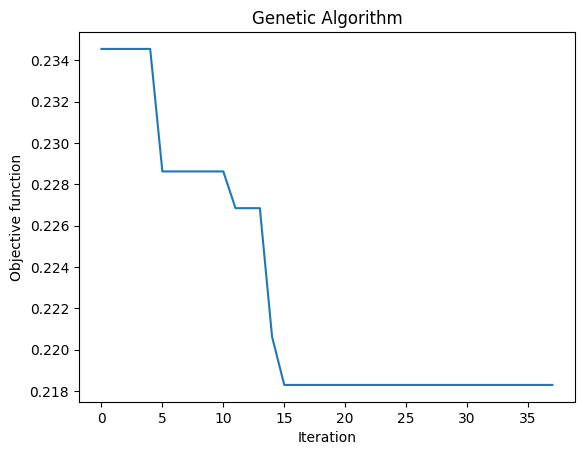

In [8]:
from geneticalgorithm import geneticalgorithm as ga
import numpy as np

# Variable bounds (integers): md∈[1,50], mss∈[2,50], msl∈[1,20], thr*100∈[20,80]
varbound = np.array([
    [1, 50],   # max_depth
    [2, 50],   # min_samples_split
    [1, 20],   # min_samples_leaf
    [20, 80],  # threshold * 100
], dtype=int)

algorithm_params = {
    'max_num_iteration': 60,
    'population_size': 30,
    'mutation_probability': 0.15,
    'elit_ratio': 0.05,
    'crossover_probability': 0.5,
    'parents_portion': 0.3,
    'crossover_type': 'uniform',
    'max_iteration_without_improv': 20
}

model = ga(function=dt_ga_objective,
           dimension=4,
           variable_type='int',
           variable_boundaries=varbound,
           algorithm_parameters=algorithm_params)

model.run()
best_variables = model.output_dict['variable']


In [9]:
from sklearn.metrics import accuracy_score

best_max_depth         = int(best_variables[0])
best_min_samples_split = int(best_variables[1])
best_min_samples_leaf  = int(best_variables[2])
best_threshold         = float(best_variables[3]) / 100.0

final_dt = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    min_samples_leaf=best_min_samples_leaf,
    class_weight="balanced",
    random_state=42
)
final_dt.fit(X_train_vect, y_train)
y_prob_test = final_dt.predict_proba(X_test_vect)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

f1 = f1_score(y_test, y_pred_test, zero_division=0)
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
acc = accuracy_score(y_test, y_pred_test)

print("Best hyperparameters found by GA:")
print(f"max_depth = {best_max_depth}, min_samples_split = {best_min_samples_split}, "
      f"min_samples_leaf = {best_min_samples_leaf}, threshold = {best_threshold:.2f}")
print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | Specificity: {spec:.4f}")


Best hyperparameters found by GA:
max_depth = 6, min_samples_split = 47, min_samples_leaf = 18, threshold = 0.75
Accuracy: 0.7073 | F1: 0.6774 | Specificity: 0.8209


## Decision Tree (BAT)

In [10]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix

# Specificity function
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np

# --- robust specificity
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# --- split TRAIN into inner-train/val for optimization (no leakage)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_vect, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# BAT params
n_bats = 10
n_iter = 20
A = 0.5       # loudness
r = 0.5       # pulse rate
f_min, f_max = 0.0, 2.0

# bounds: [max_depth, min_samples_split, threshold*100]
lb = np.array([1,  2, 30])   # thr in 0.30..0.70 (encoded as 30..70)
ub = np.array([20, 20, 70])

population = np.random.uniform(lb, ub, (n_bats, 3))
velocities = np.zeros_like(population)

def fitness(sol):
    # decode particle
    md  = int(np.clip(round(sol[0]), 1, 20))
    mss = int(np.clip(round(sol[1]), 2, 20))
    thr = float(np.clip(sol[2], 30, 70)) / 100.0

    clf = DecisionTreeClassifier(
        max_depth=md,
        min_samples_split=mss,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_tr, y_tr)                                 # <-- use embeddings
    y_prob = clf.predict_proba(X_va)[:, 1]
    y_pred = (y_prob >= thr).astype(int)

    f1  = f1_score(y_va, y_pred, zero_division=0)
    spec = specificity_score(y_va, y_pred)
    score = 0.5*f1 + 0.5*spec                           # combine F1 + specificity
    return 1.0 - score                                  # minimize

fitness_values = np.array([fitness(b) for b in population])
best_idx = int(np.argmin(fitness_values))
best_bat = population[best_idx].copy()
best_fitness = float(fitness_values[best_idx])

for t in range(n_iter):
    for i in range(n_bats):
        f = f_min + (f_max - f_min) * np.random.rand()
        velocities[i] += (population[i] - best_bat) * f
        candidate = population[i] + velocities[i]
        candidate = np.clip(candidate, lb, ub)

        if np.random.rand() > r:
            candidate = best_bat + 0.001 * np.random.randn(3)
            candidate = np.clip(candidate, lb, ub)

        Fnew = fitness(candidate)
        if (Fnew <= fitness_values[i]) and (np.random.rand() < A):
            population[i] = candidate
            fitness_values[i] = Fnew

        if Fnew < best_fitness:
            best_bat = candidate.copy()
            best_fitness = Fnew

# --- decode best and evaluate ON TEST (once)
best_md  = int(np.clip(round(best_bat[0]), 1, 20))
best_mss = int(np.clip(round(best_bat[1]), 2, 20))
best_thr = float(np.clip(best_bat[2], 30, 70)) / 100.0

final_dt = DecisionTreeClassifier(
    max_depth=best_md,
    min_samples_split=best_mss,
    class_weight="balanced",
    random_state=42
)
final_dt.fit(X_train_vect, y_train)
y_prob_test = final_dt.predict_proba(X_test_vect)[:, 1]
y_pred_test = (y_prob_test >= best_thr).astype(int)

f1  = f1_score(y_test, y_pred_test, zero_division=0)
spec = specificity_score(y_test, y_pred_test)

print("BAT best params:",
      f"max_depth={best_md}, min_samples_split={best_mss}, threshold={best_thr:.2f}")
print(f"F1={f1:.4f}  Specificity={spec:.4f}")


BAT best params: max_depth=7, min_samples_split=13, threshold=0.45
F1=0.7495  Specificity=0.7575


## Decision Tree (ACO)

In [19]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


In [20]:
# Inner validation split (avoid using test inside the search)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_vect, y_train, test_size=0.25, random_state=42, stratify=y_train
)

def fitness(solution):
    # decision tree hyperparams
    max_depth = int(np.clip(round(solution[0]), 1, 50))
    min_samples_split = int(np.clip(round(solution[1]), 2, 50))

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_tr, y_tr)
    # default threshold = 0.5 for now
    y_prob = clf.predict_proba(X_va)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    f1 = f1_score(y_va, y_pred, zero_division=0)
    spec = specificity_score(y_va, y_pred)
    # Combine F1 & specificity (you can change weights)
    return 1.0 - (0.5 * f1 + 0.5 * spec)


In [21]:
# ACO parameters
n_ants = 16
n_iter = 40
alpha = 1.0    # pheromone influence
beta  = 2.0    # heuristic influence (we'll base it on recent best)
rho   = 0.1    # evaporation

# Bounds for hyperparameters [max_depth, min_samples_split]
lb = np.array([1,  2], dtype=float)
ub = np.array([50, 50], dtype=float)

# Initialize pheromone per dimension (start neutral)
pheromone = np.ones(2, dtype=float)

best_solution = None
best_fitness  = np.inf

for it in range(n_iter):
    ants_solutions = []
    ants_fitness   = []

    # Simple heuristic: pull toward current global best if exists
    if best_solution is None:
        heuristic = np.ones(2, dtype=float)
    else:
        # heuristic ∝ closeness to best (normalized)
        heuristic = 1.0 / (np.abs((ub - lb)) + 1e-6)

    for k in range(n_ants):
        sol = []
        for d in range(2):
            # Sample within bounds with pheromone/heuristic bias
            # prob weight ~ pheromone^alpha * heuristic^beta
            weight = (pheromone[d] ** alpha) * (heuristic[d] ** beta)
            # Map a uniform random to [lb, ub], gently biased by weight
            u = np.random.rand()
            val = lb[d] + (u * weight) * (ub[d] - lb[d])
            # If weight is tiny, fall back to uniform
            if not np.isfinite(val) or val < lb[d] or val > ub[d]:
                val = lb[d] + u * (ub[d] - lb[d])
            sol.append(val)

        sol = np.clip(sol, lb, ub)
        f = fitness(sol)

        ants_solutions.append(sol)
        ants_fitness.append(f)

        if f < best_fitness:
            best_solution = np.array(sol, dtype=float)
            best_fitness  = float(f)

    ants_solutions = np.array(ants_solutions, dtype=float)
    ants_fitness   = np.array(ants_fitness, dtype=float)

    # --- pheromone update (per-dimension), inside the loop ---
    # Reward better ants (lower cost => higher deposit)
    rewards = 1.0 / (ants_fitness + 1e-12)
    mean_reward = rewards.mean()
    for d in range(2):
        pheromone[d] = (1 - rho) * pheromone[d] + rho * mean_reward

# Decode best found ints
best_md  = int(np.clip(round(best_solution[0]), lb[0], ub[0]))
best_mss = int(np.clip(round(best_solution[1]), lb[1], ub[1]))


In [22]:
# Retrain with best hyperparams on FULL train, evaluate on TEST
final_dt = DecisionTreeClassifier(
    max_depth=best_md,
    min_samples_split=best_mss,
    class_weight="balanced",
    random_state=42
)
final_dt.fit(X_train_vect, y_train)
y_prob_test = final_dt.predict_proba(X_test_vect)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)  # if you later add threshold to ACO, use it here

f1  = f1_score(y_test, y_pred_test, zero_division=0)
spec = specificity_score(y_test, y_pred_test)
acc = accuracy_score(y_test, y_pred_test)

print("Best hyperparameters found by ACO:")
print(f"max_depth = {best_md}, min_samples_split = {best_mss}")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {spec:.4f}")


Best hyperparameters found by ACO:
max_depth = 16, min_samples_split = 48
Accuracy: 0.7236
F1 Score: 0.7216
Specificity: 0.7500


## Decision Tree (Cuckoo)

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

# robust specificity
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# inner val split from TRAIN embeddings
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_vect, y_train, test_size=0.25, random_state=42, stratify=y_train
)

def dt_objective(params):
    """Minimize 1 - (0.5*F1 + 0.5*Specificity) on validation."""
    md  = int(np.clip(round(params[0]), 1, 50))
    mss = int(np.clip(round(params[1]), 2, 50))

    clf = DecisionTreeClassifier(
        max_depth=md,
        min_samples_split=mss,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(X_tr, y_tr)
    # default threshold 0.5 (see note below to optimize it)
    y_prob = clf.predict_proba(X_va)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    f1 = f1_score(y_va, y_pred, zero_division=0)
    spec = specificity_score(y_va, y_pred)
    return 1.0 - (0.5*f1 + 0.5*spec)  # cost to minimize


In [31]:
import math

def levy_flight(d, beta=1.5, rng=np.random.default_rng(42)):
    # Mantegna’s algorithm for Lévy flights
    sigma_u = (
        (math.gamma(1 + beta) * math.sin(math.pi * beta / 2))
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=d)
    v = rng.normal(0, 1, size=d)
    step = u / (np.abs(v) ** (1 / beta) + 1e-12)
    return step

def cuckoo_search(objective, n_nests=15, n_iter=60, pa=0.25, lb=None, ub=None, rng=np.random.default_rng(42)):
    lb = np.array(lb, dtype=float)
    ub = np.array(ub, dtype=float)
    dim = len(lb)

    nests = rng.uniform(lb, ub, size=(n_nests, dim))
    costs = np.array([objective(n) for n in nests], dtype=float)

    best_idx = int(np.argmin(costs))
    best = nests[best_idx].copy()
    best_cost = float(costs[best_idx])

    for _ in range(n_iter):
        # Lévy flight step
        for i in range(n_nests):
            step = levy_flight(dim, rng=rng)
            candidate = nests[i] + 0.01 * step * (nests[i] - best)
            candidate = np.minimum(np.maximum(candidate, lb), ub)
            c_cost = objective(candidate)
            if c_cost < costs[i]:
                nests[i], costs[i] = candidate, c_cost

        # Abandon fraction of nests
        abandon = rng.random(n_nests) < pa
        if np.any(abandon):
            nests[abandon] = rng.uniform(lb, ub, size=(abandon.sum(), dim))
            costs[abandon] = np.array([objective(n) for n in nests[abandon]], dtype=float)

        # Update best
        i_best = int(np.argmin(costs))
        if costs[i_best] < best_cost:
            best_cost = float(costs[i_best])
            best = nests[i_best].copy()

    return best, best_cost


In [33]:
# === FAST Cuckoo Search call (≈ 1/4 the work) ===
lb = [2, 2]          # shallower trees are faster to train
ub = [30, 40]

# tiny subsample for the SEARCH ONLY (final model will use full train)
rs = np.random.RandomState(42)
idx = rs.choice(len(X_train_vect), size=int(0.5*len(X_train_vect)), replace=False)
X_train_sub = X_train_vect[idx]
y_train_sub = y_train.iloc[idx].reset_index(drop=True)

# re-make inner split used by dt_objective
from sklearn.model_selection import train_test_split
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_sub, y_train_sub, test_size=0.25, random_state=42, stratify=y_train_sub
)

# add progress + early stop inside your cuckoo_search (minimal patch):
# (paste inside cuckoo_search loop)
#   no_improve = 0; patience = 5   # define before the for-loop
#   ...
#   if costs[i_best] < best_cost - 1e-6:
#       best_cost = float(costs[i_best]); best = nests[i_best].copy(); no_improve = 0
#   else:
#       no_improve += 1
#   if (it+1) % 5 == 0:
#       print(f"[Cuckoo] iter {it+1}/{n_iter}  best_cost={best_cost:.4f}")
#   if no_improve >= patience:
#       print(f"[Cuckoo] early stop at iter {it+1}"); break

best_params, best_cost = cuckoo_search(
    dt_objective,
    n_nests=10,   # ↓ from 20
    n_iter=40,    # ↓ from 80
    pa=0.25,
    lb=lb, ub=ub
)
print("Best (val) cost:", best_cost)
print("Best hyperparameters (md, mss):", best_params)


Best (val) cost: 0.2884359179323208
Best hyperparameters (md, mss): [5.37349052 4.22935103]


In [34]:
best_md  = int(np.clip(round(best_params[0]), lb[0], ub[0]))
best_mss = int(np.clip(round(best_params[1]), lb[1], ub[1]))

final_dt = DecisionTreeClassifier(
    max_depth=best_md,
    min_samples_split=best_mss,
    class_weight="balanced",
    random_state=42
)
final_dt.fit(X_train_vect, y_train)
y_prob_test = final_dt.predict_proba(X_test_vect)[:, 1]
y_pred_test = (y_prob_test >= 0.5).astype(int)

f1  = f1_score(y_test, y_pred_test, zero_division=0)
spec = specificity_score(y_test, y_pred_test)
acc = accuracy_score(y_test, y_pred_test)

print(f"Final DecisionTree (Cuckoo) — md={best_md}, mss={best_mss}")
print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | Specificity: {spec:.4f}")


Final DecisionTree (Cuckoo) — md=5, mss=4
Accuracy: 0.7382 | F1: 0.7382 | Specificity: 0.7575


## Decision Tree (Firefly Algo)

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Use a larger subset for better DT fit (80% of train). Final model uses full train.
rs = np.random.RandomState(42)
sub_idx = rs.choice(len(X_train_vect), size=int(0.8 * len(X_train_vect)), replace=False)
X_train_sub = X_train_vect[sub_idx]
y_train_sub = y_train.iloc[sub_idx].reset_index(drop=True)

# Inner validation split for objective (no test leakage)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_sub, y_train_sub, test_size=0.25, random_state=42, stratify=y_train_sub
)


In [7]:
# Search-space: [max_depth, min_samples_split, min_samples_leaf, criterion_id, thr*100]
# criterion_id: 0=gini, 1=entropy, 2=log_loss
LB = np.array([  2,  2,  1, 0, 20.0], dtype=float)
UB = np.array([200, 60, 30, 2, 80.0], dtype=float)

def decode(sol):
    md   = int(np.clip(np.round(sol[0]), LB[0], UB[0]))
    mss  = int(np.clip(np.round(sol[1]), LB[1], UB[1]))
    msl  = int(np.clip(np.round(sol[2]), LB[2], UB[2]))
    cid  = int(np.clip(np.round(sol[3]), LB[3], UB[3]))
    thr  = float(np.clip(sol[4], LB[4], UB[4])) / 100.0
    criterion = ["gini", "entropy", "log_loss"][cid]
    return md, mss, msl, criterion, thr

def best_acc_threshold(y_true, prob, grid=101):
    # scan thresholds to maximize ACC on validation (fast)
    ths = np.linspace(0.05, 0.95, grid)
    accs = []
    for t in ths:
        accs.append(accuracy_score(y_true, (prob >= t).astype(int)))
    i = int(np.argmax(accs))
    return float(ths[i]), float(accs[i])

def dt_objective(sol):
    # minimize cost = 1 - accuracy (with threshold tuned)
    md, mss, msl, criterion, thr_guess = decode(sol)

    clf = DecisionTreeClassifier(
        max_depth=md,
        min_samples_split=mss,
        min_samples_leaf=msl,
        criterion=criterion,
        random_state=42
    )
    clf.fit(X_tr, y_tr)
    prob = clf.predict_proba(X_va)[:, 1]

    # choose the better of guessed thr and scanned thr
    thr_scan, acc_scan = best_acc_threshold(y_va, prob, grid=101)
    acc_guess = accuracy_score(y_va, (prob >= thr_guess).astype(int))
    acc = max(acc_scan, acc_guess)

    return 1.0 - acc


In [8]:
def firefly_optimize(
    objective, lb, ub,
    n_fireflies=22, iters=70,      # still well within an hour for this dataset
    alpha=0.25, beta0=1.0, gamma=1.0,
    patience=10, seed=42
):
    rng = np.random.default_rng(seed)
    lb = np.array(lb, dtype=float); ub = np.array(ub, dtype=float)
    dim = len(lb)

    X = rng.uniform(lb, ub, size=(n_fireflies, dim))
    F = np.array([objective(x) for x in X], dtype=float)
    best_idx = int(np.argmin(F)); best_x = X[best_idx].copy(); best_f = float(F[best_idx])

    no_improve = 0
    for it in range(iters):
        for i in range(n_fireflies):
            for j in range(n_fireflies):
                if F[j] < F[i]:
                    r = np.linalg.norm(X[i] - X[j]) / (np.linalg.norm(ub - lb) + 1e-12)
                    beta = beta0 * np.exp(-gamma * r * r)
                    step = beta * (X[j] - X[i]) + alpha * rng.normal(0, 1, size=dim)
                    X[i] = np.minimum(np.maximum(X[i] + step, lb), ub)
                    Fi = objective(X[i])
                    if Fi < F[i]:
                        F[i] = Fi

        cur_idx = int(np.argmin(F)); cur_best = float(F[cur_idx])
        if cur_best < best_f - 1e-6:
            best_f = cur_best; best_x = X[cur_idx].copy(); no_improve = 0
        else:
            no_improve += 1

        if (it + 1) % 5 == 0:
            print(f"[FA] iter {it+1}/{iters} — best_cost={best_f:.4f}")
        if no_improve >= patience:
            print(f"[FA] Early stop at iter {it+1} (no improvement {patience} iters).")
            break

        alpha *= 0.98  # gentle cooling

    return best_x, best_f

best_sol, best_cost = firefly_optimize(
    dt_objective, LB, UB,
    n_fireflies=22, iters=70, alpha=0.25, beta0=1.0, gamma=1.0, patience=10, seed=42
)
best_md, best_mss, best_msl, best_crit, best_thr = decode(best_sol)
print("Best (val) cost:", best_cost)
print(f"Best params: md={best_md}, mss={best_mss}, msl={best_msl}, crit={best_crit}, thr={best_thr:.2f}")


[FA] iter 5/70 — best_cost=0.2273
[FA] iter 10/70 — best_cost=0.2273
[FA] Early stop at iter 10 (no improvement 10 iters).
Best (val) cost: 0.2272727272727273
Best params: md=42, mss=2, msl=24, crit=entropy, thr=0.62


In [9]:
# Retrain full model with best hyperparams
final_dt = DecisionTreeClassifier(
    max_depth=best_md,
    min_samples_split=best_mss,
    min_samples_leaf=best_msl,
    criterion=best_crit,
    random_state=42
)
final_dt.fit(X_train_vect, y_train)

prob_test = final_dt.predict_proba(X_test_vect)[:, 1]

# To squeeze max accuracy, re-scan threshold on FULL TRAIN and reuse it for TEST
prob_train_full = final_dt.predict_proba(X_train_vect)[:, 1]
thr_full, _ = (lambda y,p: (np.linspace(0.05,0.95,201)[np.argmax([accuracy_score(y,(p>=t).astype(int)) for t in np.linspace(0.05,0.95,201)])],
                            None))(y_train, prob_train_full)

# Use the better of FA-found threshold vs train-full threshold
thr_final = max([(best_thr, accuracy_score(y_train, (prob_train_full >= best_thr).astype(int))),
                 (thr_full, accuracy_score(y_train, (prob_train_full >= thr_full).astype(int)))],
                key=lambda x: x[1])[0]

y_pred_test = (prob_test >= thr_final).astype(int)

acc = accuracy_score(y_test, y_pred_test)
f1  = f1_score(y_test, y_pred_test, zero_division=0)
spec = specificity_score(y_test, y_pred_test)

print(f"[FA + DT tuned for ACC]  Accuracy={acc:.4f}  F1={f1:.4f}  Specificity={spec:.4f}")
print(f"Final params: max_depth={best_md}, min_samples_split={best_mss}, min_samples_leaf={best_msl}, "
      f"criterion={best_crit}, threshold={thr_final:.2f}")


[FA + DT tuned for ACC]  Accuracy=0.7345  F1=0.7439  Specificity=0.7164
Final params: max_depth=42, min_samples_split=2, min_samples_leaf=24, criterion=entropy, threshold=0.49


## Decision Tree (ABC)

# Support Vector Machines

## Vector embeddings 

In [2]:
import pandas as pd
import numpy as np

# Load all three TSV files
data1 = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
data2 = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
data3 = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])

# Concatenate them
data = pd.concat([data1, data2, data3], ignore_index=True)

# Shuffle (optional but good practice)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples after merging: {len(data)}")
print(data.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)
from transformers import BertTokenizer, BertModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

def get_bert_embeddings(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(emb)
    return np.concatenate(all_embeddings, axis=0)

# Run embedding extraction
X_train_vect = get_bert_embeddings(X_train)
X_test_vect = get_bert_embeddings(X_test)

Total samples after merging: 2748
                                                text  label
0  The attractive set used throughout most of the...      1
1  This was one of the worst films i have ever se...      0
2  The microphone also works well, but (according...      1
3  * Comes with a strong light that you can use t...      1
4  The acting is like watching wooden puppets mov...      0
Using device: cpu


## PSO

In [2]:
# --- PSO + SVM (optimize for F1, report F1 & Specificity) ---

import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- Helper: compute specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ---- PSO implementation (simple, dependency-free)
rng = np.random.default_rng(42)

# We’ll search in log-space for stability:
# log10(C) in [-2, 3]  -> C in [1e-2, 1e3]
# log10(gamma) in [-4, 1] -> gamma in [1e-4, 10]
bounds_low  = np.array([-2.0, -4.0])
bounds_high = np.array([ 3.0,  1.0])

def decode_params(x):
    logC, logG = x
    C = 10.0 ** logC
    gamma = 10.0 ** logG
    return C, gamma

def objective(x):
    """Return NEGATIVE mean CV F1 (PSO minimizes). x is shape (2,) in log-space."""
    C, gamma = decode_params(x)
    clf = SVC(kernel="rbf", C=C, gamma=gamma, probability=False, class_weight="balanced", random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train_vect, y_train_arr, scoring="f1", cv=cv, n_jobs=-1)
    return -np.mean(scores)

def pso_optimize(
    n_particles=30, n_iters=40, w=0.72, c1=1.49, c2=1.49,
    bounds_low=bounds_low, bounds_high=bounds_high
):
    dim = len(bounds_low)
    # init particles uniformly in bounds
    pos = rng.uniform(bounds_low, bounds_high, size=(n_particles, dim))
    vel = rng.normal(0, 0.5, size=(n_particles, dim))

    # personal bests
    pbest_pos = pos.copy()
    pbest_val = np.array([objective(p) for p in pbest_pos])

    # global best
    g_idx = np.argmin(pbest_val)
    gbest_pos = pbest_pos[g_idx].copy()
    gbest_val = pbest_val[g_idx]

    for it in range(n_iters):
        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))

        # velocity & position updates
        vel = w*vel + c1*r1*(pbest_pos - pos) + c2*r2*(gbest_pos - pos)
        pos = pos + vel

        # enforce bounds
        pos = np.maximum(pos, bounds_low)
        pos = np.minimum(pos, bounds_high)

        # evaluate
        vals = np.array([objective(p) for p in pos])

        # update personal best
        improved = vals < pbest_val
        pbest_pos[improved] = pos[improved]
        pbest_val[improved] = vals[improved]

        # update global best
        g_idx = np.argmin(pbest_val)
        if pbest_val[g_idx] < gbest_val:
            gbest_val = pbest_val[g_idx]
            gbest_pos = pbest_pos[g_idx].copy()

        print(f"Iter {it+1:02d}/{n_iters} | best CV F1 = {-gbest_val:.4f}", flush=True)

    return gbest_pos, -gbest_val

# ---- Run PSO
best_pos, best_cv_f1 = pso_optimize(
    n_particles=30,   # you can increase if time allows
    n_iters=40,       # likewise
)

best_C, best_gamma = decode_params(best_pos)
print(f"\nBest hyperparams (PSO): C={best_C:.5f}, gamma={best_gamma:.5f} | CV F1={best_cv_f1:.4f}")

# ---- Train final SVM and evaluate
svm_best = SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=42)
svm_best.fit(X_train_vect, y_train_arr)

y_pred = svm_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
test_spec = specificity_score(y_test_arr, y_pred)

print(f"Test F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Iter 01/40 | best CV F1 = 0.9150
Iter 02/40 | best CV F1 = 0.9183
Iter 03/40 | best CV F1 = 0.9188
Iter 04/40 | best CV F1 = 0.9188
Iter 05/40 | best CV F1 = 0.9188
Iter 06/40 | best CV F1 = 0.9188
Iter 07/40 | best CV F1 = 0.9188
Iter 08/40 | best CV F1 = 0.9188
Iter 09/40 | best CV F1 = 0.9188
Iter 10/40 | best CV F1 = 0.9188
Iter 11/40 | best CV F1 = 0.9188
Iter 12/40 | best CV F1 = 0.9188
Iter 13/40 | best CV F1 = 0.9188
Iter 14/40 | best CV F1 = 0.9188
Iter 15/40 | best CV F1 = 0.9192
Iter 16/40 | best CV F1 = 0.9192
Iter 17/40 | best CV F1 = 0.9192
Iter 18/40 | best CV F1 = 0.9192
Iter 19/40 | best CV F1 = 0.9192
Iter 20/40 | best CV F1 = 0.9192
Iter 21/40 | best CV F1 = 0.9192
Iter 22/40 | best CV F1 = 0.9192
Iter 23/40 | best CV F1 = 0.9192
Iter 24/40 | best CV F1 = 0.9192
Iter 25/40 | best CV F1 = 0.9192
Iter 26/40 | best CV F1 = 0.9192
Iter 27/40 | best CV F1 = 0.9192
Iter 28/40 | best CV F1 = 0.9192
Iter 29/40 | best CV F1 = 0.9192
Iter 30/40 | best CV F1 = 0.9192
Iter 31/40

c:\Users\ANIRUDDUHA\anaconda3\envs\tech\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Iter 35/40 | best CV F1 = 0.9192
Iter 36/40 | best CV F1 = 0.9192
Iter 37/40 | best CV F1 = 0.9192
Iter 38/40 | best CV F1 = 0.9192
Iter 39/40 | best CV F1 = 0.9192
Iter 40/40 | best CV F1 = 0.9192

Best hyperparams (PSO): C=5.68676, gamma=0.00725 | CV F1=0.9192
Test F1: 0.8977
Test Specificity: 0.9067


## GA

In [5]:
# -------- Fast GA + SVM (memoized, fixed CV splits, 3-fold, early stop) --------
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ---- Tighter bounds (speeds convergence) ----
BOUNDS_LOW  = np.array([-2.0, -4.0])  # C in [1e-2, 1e3], gamma in [1e-4, 1]
BOUNDS_HIGH = np.array([ 3.0,  0.0])

def decode_params(x):
    logC, logG = x
    return 10.0**logC, 10.0**logG

USE_COMPOSITE = False
rng = np.random.default_rng(42)

# ---- Precompute fixed CV splits (3-fold for speed) ----
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_indices = [(tr, va) for tr, va in cv.split(X_train_vect, y_train_arr)]

# ---- Memoized objective (rounding keys to reduce near-duplicate evals) ----
def _score_with_cv(C, gamma):
    # Pipeline (scaler+svc)
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=42))
    ])
    f1s, specs = [], []
    for tr, va in cv_indices:
        pipe.fit(X_train_vect[tr], y_train_arr[tr])
        preds = pipe.predict(X_train_vect[va])
        f1s.append(f1_score(y_train_arr[va], preds))
        if USE_COMPOSITE:
            specs.append(specificity_score(y_train_arr[va], preds))
    f1m = float(np.mean(f1s))
    if not USE_COMPOSITE:
        return f1m
    return 0.7 * f1m + 0.3 * float(np.mean(specs))

@lru_cache(maxsize=2048)
def objective_cached(logC_rounded, logG_rounded):
    C = 10.0 ** logC_rounded
    gamma = 10.0 ** logG_rounded
    return -_score_with_cv(C, gamma)

def objective(x):
    # Round to 3 decimals in log space -> ~0.1% steps on C/gamma; big cache hits
    logC_r = float(np.round(x[0], 3))
    logG_r = float(np.round(x[1], 3))
    return objective_cached(logC_r, logG_r)

# ---- GA pieces (unchanged structure) ----
def init_pop(pop_size, dim):
    return rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(pop_size, dim))

def tournament_select(pop, fitness, k=3):
    idxs = rng.integers(0, len(pop), size=k)
    return pop[idxs[np.argmin(fitness[idxs])]].copy()

def uniform_crossover(p1, p2, cx_prob=0.5):
    mask = rng.random(p1.shape) < cx_prob
    return np.where(mask, p1, p2)

def gaussian_mutation(x, sigma=0.15, mut_prob=0.25):
    mask = rng.random(x.shape) < mut_prob
    x_new = np.where(mask, x + rng.normal(0, sigma, size=x.shape), x)
    return np.maximum(np.minimum(x_new, BOUNDS_HIGH), BOUNDS_LOW)

def evolve_ga(
    pop_size=20, n_gens=20, elite_frac=0.15,
    cx_prob=0.6, mut_prob=0.25, sigma=0.18, tournament_k=3,
    patience=5
):
    dim = 2
    pop = init_pop(pop_size, dim)
    fitness = np.array([objective(ind) for ind in pop])
    n_elite = max(1, int(elite_frac * pop_size))

    best_hist = []
    best_so_far = -fitness.min()
    no_improve = 0

    for gen in range(n_gens):
        elite_idx = np.argsort(fitness)[:n_elite]
        elites = pop[elite_idx].copy()

        offspring = []
        while len(offspring) < pop_size - n_elite:
            p1 = tournament_select(pop, fitness, k=tournament_k)
            p2 = tournament_select(pop, fitness, k=tournament_k)
            child = uniform_crossover(p1, p2, cx_prob=cx_prob)
            child = gaussian_mutation(child, sigma=sigma, mut_prob=mut_prob)
            offspring.append(child)
        offspring = np.array(offspring)

        off_fit = np.array([objective(ind) for ind in offspring])

        pop = np.vstack([elites, offspring])
        fitness = np.hstack([fitness[elite_idx], off_fit])

        best = -fitness.min()
        best_hist.append(best)
        print(f"Gen {gen+1:02d}/{n_gens} | best CV score = {best:.4f}", flush=True)

        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at gen {gen+1} (no improvement {patience} gens).")
                break

    best_idx = np.argmin(fitness)
    return pop[best_idx], -fitness[best_idx]

# ---- Run fast GA
best_pos, best_cv = evolve_ga(
    pop_size=20,
    n_gens=20,
    elite_frac=0.15,
    cx_prob=0.55,
    mut_prob=0.25,
    sigma=0.18,
    tournament_k=3,
    patience=5
)

best_C, best_gamma = decode_params(best_pos)
print(f"\n[GA-fast] Best: C={best_C:.6f}, gamma={best_gamma:.6f} | CV={best_cv:.4f} ({'F1' if not USE_COMPOSITE else '0.7*F1+0.3*Spec'})")

# ---- Final train on full train, evaluate test (unchanged) ----
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)

print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):.4f}")


Gen 01/20 | best CV score = 0.9157
Gen 02/20 | best CV score = 0.9162
Gen 03/20 | best CV score = 0.9173
Gen 04/20 | best CV score = 0.9174
Gen 05/20 | best CV score = 0.9174
Gen 06/20 | best CV score = 0.9183
Gen 07/20 | best CV score = 0.9183
Gen 08/20 | best CV score = 0.9195
Gen 09/20 | best CV score = 0.9195
Gen 10/20 | best CV score = 0.9195
Gen 11/20 | best CV score = 0.9195
Gen 12/20 | best CV score = 0.9195
Gen 13/20 | best CV score = 0.9195
Early stopping at gen 13 (no improvement 5 gens).

[GA-fast] Best: C=2.126192, gamma=0.001544 | CV=0.9195 (F1)
Test F1: 0.9052
Test Specificity: 0.9104


## Bat Algorithm

In [6]:
# -------- Fast BAT + SVM (memoized, fixed 3-fold CV, early stop) --------
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ---- Tighter bounds (works well for BERT embeddings) ----
# C in [1e-2, 1e3], gamma in [1e-4, 1]
BOUNDS_LOW  = np.array([-2.0, -4.0])
BOUNDS_HIGH = np.array([ 3.0,  0.0])

def decode_params(x):
    logC, logG = x
    return 10.0**logC, 10.0**logG

USE_COMPOSITE = False
rng = np.random.default_rng(42)

# ---- Fixed 3-fold CV indices for speed & stability ----
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_indices = [(tr, va) for tr, va in cv.split(X_train_vect, y_train_arr)]

def _score_with_cv(C, gamma):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=42))
    ])
    f1s, specs = [], []
    for tr, va in cv_indices:
        pipe.fit(X_train_vect[tr], y_train_arr[tr])
        preds = pipe.predict(X_train_vect[va])
        f1s.append(f1_score(y_train_arr[va], preds))
        if USE_COMPOSITE:
            specs.append(specificity_score(y_train_arr[va], preds))
    f1m = float(np.mean(f1s))
    if not USE_COMPOSITE:
        return f1m
    return 0.7 * f1m + 0.3 * float(np.mean(specs))

# ---- Memoize objective (round keys for cache hits) ----
@lru_cache(maxsize=2048)
def objective_cached(logC_r, logG_r):
    return -_score_with_cv(10.0**logC_r, 10.0**logG_r)

def objective(x):
    logC_r = float(np.round(x[0], 3))
    logG_r = float(np.round(x[1], 3))
    return objective_cached(logC_r, logG_r)

# ---- Fast Bat Algorithm ----
def bat_optimize(
    n_bats=20, n_iters=25,
    fmin=0.0, fmax=2.0,
    A0=0.9, r0=0.6, alpha=0.9, gamma_bat=0.9,
    step_local=0.05,
    patience=5  # early stop if no improvement for N iters
):
    dim = 2
    pos = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_bats, dim))
    vel = np.zeros((n_bats, dim))
    freq = np.zeros(n_bats)
    A = np.full(n_bats, A0)
    r = np.full(n_bats, r0)

    fit = np.array([objective(p) for p in pos])
    best_idx = np.argmin(fit)
    gbest = pos[best_idx].copy()
    gbest_val = fit[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        for i in range(n_bats):
            # frequency / velocity / position
            freq[i] = fmin + (fmax - fmin) * rng.random()
            vel[i] = vel[i] + (pos[i] - gbest) * freq[i]
            cand = pos[i] + vel[i]

            # local random walk
            if rng.random() > r[i]:
                eps = rng.normal(0, 1, size=dim)
                cand = gbest + step_local * A.mean() * eps

            # bounds
            cand = np.maximum(cand, BOUNDS_LOW)
            cand = np.minimum(cand, BOUNDS_HIGH)

            cand_fit = objective(cand)

            # accept move
            if (cand_fit <= fit[i]) and (rng.random() < A[i]):
                pos[i] = cand
                fit[i] = cand_fit
                A[i] = alpha * A[i]
                r[i] = r0 * (1 - np.exp(-gamma_bat * (it+1)))

            if fit[i] < gbest_val:
                gbest_val = fit[i]
                gbest = pos[i].copy()

        best = -gbest_val
        print(f"Iter {it+1:02d}/{n_iters} | best CV score = {best:.4f}", flush=True)

        # early stopping
        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1} (no improvement {patience} iters).")
                break

    return gbest, -gbest_val

# ---- Run fast BAT
best_pos, best_cv = bat_optimize(
    n_bats=20,      # was 30
    n_iters=25,     # was 40
    fmin=0.0, fmax=2.0,
    A0=0.9, r0=0.6, alpha=0.9, gamma_bat=0.9,
    step_local=0.05,
    patience=5
)

best_C, best_gamma = decode_params(best_pos)
print(f"\n[BAT-fast] Best: C={best_C:.6f}, gamma={best_gamma:.6f} | CV={best_cv:.4f} ({'F1' if not USE_COMPOSITE else '0.7*F1+0.3*Spec'})")

# ---- Final train & evaluate
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)

print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):.4f}")


Iter 01/25 | best CV score = 0.9173
Iter 02/25 | best CV score = 0.9177
Iter 03/25 | best CV score = 0.9186
Iter 04/25 | best CV score = 0.9186
Iter 05/25 | best CV score = 0.9186
Iter 06/25 | best CV score = 0.9186
Iter 07/25 | best CV score = 0.9186
Iter 08/25 | best CV score = 0.9186
Early stopping at iter 8 (no improvement 5 iters).

[BAT-fast] Best: C=1.415561, gamma=0.001052 | CV=0.9186 (F1)
Test F1: 0.9078
Test Specificity: 0.9254


## Cukoo

In [8]:
# -------- Fast Cuckoo Search (Lévy) + SVM (optimize F1; report F1 & Specificity) --------
# at the top with your imports
import math
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- Metrics
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ---- Search bounds in log10 (good defaults for BERT embeddings)
# C in [1e-2, 1e3], gamma in [1e-4, 1]
BOUNDS_LOW  = np.array([-2.0, -4.0])
BOUNDS_HIGH = np.array([ 3.0,  0.0])

def decode_params(x):
    logC, logG = x
    return 10.0**logC, 10.0**logG

USE_COMPOSITE = False  # set True to optimize 0.7*F1 + 0.3*Specificity

rng = np.random.default_rng(42)

# ---- Fixed 3-fold CV indices for speed & stability
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_indices = [(tr, va) for tr, va in cv.split(X_train_vect, y_train_arr)]

def _score_with_cv(C, gamma):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=42))
    ])
    f1s, specs = [], []
    for tr, va in cv_indices:
        pipe.fit(X_train_vect[tr], y_train_arr[tr])
        preds = pipe.predict(X_train_vect[va])
        f1s.append(f1_score(y_train_arr[va], preds))
        if USE_COMPOSITE:
            specs.append(specificity_score(y_train_arr[va], preds))
    f1m = float(np.mean(f1s))
    if not USE_COMPOSITE:
        return f1m
    return 0.7 * f1m + 0.3 * float(np.mean(specs))

# ---- Memoize objective (round in log space to amplify cache hits)
@lru_cache(maxsize=4096)
def objective_cached(logC_r, logG_r):
    return -_score_with_cv(10.0**logC_r, 10.0**logG_r)

def objective(x):
    logC_r = float(np.round(x[0], 3))
    logG_r = float(np.round(x[1], 3))
    return objective_cached(logC_r, logG_r)

# ---- Lévy flight generator (Mantegna's algorithm)
def levy_flight(dim, beta=1.5, rng=rng):
    # Mantegna's algorithm
    # sigma_u as in Yang & Deb / Mantegna
    sigma_u = (
        (math.gamma(1 + beta) * math.sin(math.pi * beta / 2)) /
        (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = rng.normal(0, sigma_u, size=dim)
    v = rng.normal(0, 1, size=dim)
    step = u / (np.abs(v) ** (1 / beta) + 1e-12)
    return step


# ---- Cuckoo Search (Yang & Deb style)
def cuckoo_search(
    n_nests=20, n_iters=25, pa=0.25, alpha=0.05, beta=1.5,
    elite_frac=0.15, patience=5
):
    dim = 2
    # init nests
    nests = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_nests, dim))
    fitness = np.array([objective(x) for x in nests])  # lower is better (negative score)
    n_elite = max(1, int(elite_frac * n_nests))

    best_idx = np.argmin(fitness)
    gbest = nests[best_idx].copy()
    gbest_val = fitness[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        # 1) Generate new solutions via Lévy flights from random nests
        new_nests = nests.copy()
        for i in range(n_nests):
            step = levy_flight(dim, beta=beta)
            cand = nests[i] + alpha * step * (nests[i] - gbest)
            # bounds
            cand = np.maximum(cand, BOUNDS_LOW)
            cand = np.minimum(cand, BOUNDS_HIGH)
            cand_fit = objective(cand)
            # greedy replace
            if cand_fit < fitness[i]:
                new_nests[i] = cand
                fitness[i] = cand_fit

        nests = new_nests

        # 2) Abandon a fraction pa of worst nests and reinitialize
        idx_sorted = np.argsort(fitness)  # ascending (best first)
        elites = nests[idx_sorted[:n_elite]].copy()
        worst_idx = idx_sorted[int((1 - pa) * n_nests):]
        if len(worst_idx) > 0:
            nests[worst_idx] = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(len(worst_idx), dim))
            # evaluate the reinitialized ones
            for wi in worst_idx:
                fitness[wi] = objective(nests[wi])

        # keep elites (elitism)
        nests[idx_sorted[:n_elite]] = elites

        # update global best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < gbest_val:
            gbest_val = fitness[best_idx]
            gbest = nests[best_idx].copy()

        best = -gbest_val
        print(f"Iter {it+1:02d}/{n_iters} | best CV score = {best:.4f}", flush=True)

        # early stopping
        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1} (no improvement {patience} iters).")
                break

    return gbest, -gbest_val

# ---- Run fast Cuckoo Search
best_pos, best_cv = cuckoo_search(
    n_nests=20,      # fewer nests than typical (faster)
    n_iters=25,      # fewer iterations (faster)
    pa=0.25,         # discovery rate
    alpha=0.06,      # step size for Lévy flights
    beta=1.5,        # Lévy exponent
    elite_frac=0.15,
    patience=5
)

best_C, best_gamma = decode_params(best_pos)
print(f"\n[CUCKOO-fast] Best: C={best_C:.6f}, gamma={best_gamma:.6f} | CV={best_cv:.4f} ({'F1' if not USE_COMPOSITE else '0.7*F1+0.3*Spec'})")

# ---- Final train on full train and evaluate on test
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)

print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):.4f}")


Iter 01/25 | best CV score = 0.9157
Iter 02/25 | best CV score = 0.9162
Iter 03/25 | best CV score = 0.9166
Iter 04/25 | best CV score = 0.9166
Iter 05/25 | best CV score = 0.9166
Iter 06/25 | best CV score = 0.9168
Iter 07/25 | best CV score = 0.9168
Iter 08/25 | best CV score = 0.9168
Iter 09/25 | best CV score = 0.9168
Iter 10/25 | best CV score = 0.9168
Iter 11/25 | best CV score = 0.9168
Early stopping at iter 11 (no improvement 5 iters).

[CUCKOO-fast] Best: C=1.741954, gamma=0.001699 | CV=0.9168 (F1)
Test F1: 0.8993
Test Specificity: 0.9104


## ACO

In [9]:
# -------- Fast ACO (ACOR) + SVM (optimize F1; report F1 & Specificity) --------
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- Metrics
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ---- Tight bounds in log10 (good defaults for BERT embeddings)
# C in [1e-2, 1e3], gamma in [1e-4, 1]
BOUNDS_LOW  = np.array([-2.0, -4.0])
BOUNDS_HIGH = np.array([ 3.0,  0.0])

def decode_params(x):
    logC, logG = x
    return 10.0**logC, 10.0**logG

USE_COMPOSITE = False
rng = np.random.default_rng(42)

# ---- Fixed 3-fold CV indices for speed & stability
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_indices = [(tr, va) for tr, va in cv.split(X_train_vect, y_train_arr)]

def _score_with_cv(C, gamma):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=42))
    ])
    f1s, specs = [], []
    for tr, va in cv_indices:
        pipe.fit(X_train_vect[tr], y_train_arr[tr])
        preds = pipe.predict(X_train_vect[va])
        f1s.append(f1_score(y_train_arr[va], preds))
        if USE_COMPOSITE:
            specs.append(specificity_score(y_train_arr[va], preds))
    f1m = float(np.mean(f1s))
    if not USE_COMPOSITE:
        return f1m
    return 0.7 * f1m + 0.3 * float(np.mean(specs))

# ---- Memoize objective (round in log space to amplify cache hits)
@lru_cache(maxsize=4096)
def objective_cached(logC_r, logG_r):
    return -_score_with_cv(10.0**logC_r, 10.0**logG_r)

def objective(x):
    logC_r = float(np.round(x[0], 3))
    logG_r = float(np.round(x[1], 3))
    return objective_cached(logC_r, logG_r)

# ---- ACOR (Socha-style) for continuous optimization
def acor_optimize(
    m_ants=15,            # ants generated per iter
    Q=30,                 # archive size
    n_iters=25,
    q_intensity=0.25,     # selection pressure (smaller -> more greedy)
    xi=0.85,              # exploration (sigma multiplier)
    patience=5            # early stop if no improvement for N iters
):
    dim = 2
    # Initialize archive uniformly in bounds
    archive = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(Q, dim))
    fitness = np.array([objective(a) for a in archive])  # lower is better (neg score)

    # Weights for kernels (rank-based)
    # w_i ∝ exp(- (i-1)^2 / (2 * (q_intensity*Q)^2)), i is rank (1=best)
    def compute_weights(Q, q):
        ranks = np.arange(1, Q+1)
        sigma = q * Q
        w = np.exp(-((ranks - 1)**2) / (2 * sigma * sigma + 1e-12))
        w /= w.sum()
        return w

    weights = compute_weights(Q, q_intensity)

    best_idx = np.argmin(fitness)
    gbest = archive[best_idx].copy()
    gbest_val = fitness[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        # Sort archive by fitness (ascending)
        order = np.argsort(fitness)
        archive = archive[order]
        fitness = fitness[order]

        # Compute per-dimension std (for kernels)
        # Use rank-weighted std to adapt sampling widths
        mu = np.average(archive, axis=0, weights=np.flip(weights))  # not critical which way; consistent use
        std = np.sqrt(np.average((archive - mu)**2, axis=0, weights=np.flip(weights))) + 1e-9

        # Generate m_ants new solutions via Gaussian kernels centered at selected elites
        new_solutions = []
        new_fits = []
        for _ in range(m_ants):
            # choose index from {0..Q-1} using weights (best has highest prob)
            idx = rng.choice(Q, p=weights)
            center = archive[idx]
            sigma = xi * std
            cand = center + rng.normal(0, sigma, size=dim)
            # enforce bounds
            cand = np.maximum(cand, BOUNDS_LOW)
            cand = np.minimum(cand, BOUNDS_HIGH)
            f = objective(cand)
            new_solutions.append(cand)
            new_fits.append(f)

        # Merge and keep best Q (elitism by truncation)
        archive = np.vstack([archive, np.array(new_solutions)])
        fitness = np.hstack([fitness, np.array(new_fits)])
        order = np.argsort(fitness)
        archive = archive[order][:Q]
        fitness = fitness[order][:Q]

        # Update global best
        if fitness[0] < gbest_val:
            gbest_val = fitness[0]
            gbest = archive[0].copy()

        best = -gbest_val
        print(f"Iter {it+1:02d}/{n_iters} | best CV score = {best:.4f}", flush=True)

        # Early stopping
        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1} (no improvement {patience} iters).")
                break

    return gbest, -gbest_val

# ---- Run fast ACOR
best_pos, best_cv = acor_optimize(
    m_ants=15,     # fewer samples per iter
    Q=30,          # archive size
    n_iters=25,    # fewer iterations
    q_intensity=0.25,
    xi=0.85,
    patience=5
)

best_C, best_gamma = decode_params(best_pos)
print(f"\n[ACO-fast] Best: C={best_C:.6f}, gamma={best_gamma:.6f} | CV={best_cv:.4f} ({'F1' if not USE_COMPOSITE else '0.7*F1+0.3*Spec'})")

# ---- Final train on full train and evaluate on test
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=best_C, gamma={best_gamma}, class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)

print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred)::.4f}")


Iter 01/25 | best CV score = 0.9157
Iter 02/25 | best CV score = 0.9157
Iter 03/25 | best CV score = 0.9157
Iter 04/25 | best CV score = 0.9157
Iter 05/25 | best CV score = 0.9178
Iter 06/25 | best CV score = 0.9178
Iter 07/25 | best CV score = 0.9178
Iter 08/25 | best CV score = 0.9181
Iter 09/25 | best CV score = 0.9186
Iter 10/25 | best CV score = 0.9186
Iter 11/25 | best CV score = 0.9186
Iter 12/25 | best CV score = 0.9186
Iter 13/25 | best CV score = 0.9186
Iter 14/25 | best CV score = 0.9186
Early stopping at iter 14 (no improvement 5 iters).

[ACO-fast] Best: C=2.199202, gamma=0.001519 | CV=0.9186 (F1)


InvalidParameterError: The 'gamma' parameter of SVC must be a str among {'scale', 'auto'} or a float in the range [0.0, inf). Got {np.float64(0.0015186253232968702)} instead.

## FA

In [11]:
# ---------- FIREFLY Ultra-Fast: 1D (optimize C only, gamma='scale') ----------
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(tr_idx, va_idx), = sss.split(X_train_vect, y_train_arr)

# metric
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# bounds in log10(C): C in [1e-2, 1e3]
BOUNDS_LOW  = np.array([-2.0])
BOUNDS_HIGH = np.array([ 3.0])

def decode_params_1d(x):
    return 10.0**x[0]

def _score_holdout_C(C):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced", random_state=42))
    ])
    pipe.fit(X_train_vect[tr_idx], y_train_arr[tr_idx])
    preds = pipe.predict(X_train_vect[va_idx])
    return f1_score(y_train_arr[va_idx], preds)

@lru_cache(maxsize=1024)
def objective_cached_1d(logC_r):
    return -_score_holdout_C(10.0**logC_r)

def objective_1d(x):
    return objective_cached_1d(float(np.round(x[0], 2)))  # coarse rounding -> big cache hits

def firefly_optimize_1d(
    n_fireflies=16, n_iters=18, top_k=5,
    alpha=0.30, alpha_damp=0.94, beta0=1.0, gamma_ff=1.0,
    patience=4
):
    dim = 1
    rng = np.random.default_rng(42)
    X = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_fireflies, dim))
    F = np.array([objective_1d(x) for x in X])
    best_so_far = -F.min(); no_improve = 0

    for it in range(n_iters):
        # sort once; interact only with top_k brighter
        order = np.argsort(F); X = X[order]; F = F[order]
        kcap = min(top_k, n_fireflies-1)

        for i in range(n_fireflies):
            j = np.random.randint(0, kcap)  # target among best few
            if j == i: j = (j+1) % kcap
            r = np.linalg.norm(X[i] - X[j])
            beta = beta0 * np.exp(-gamma_ff * r * r)
            cand = X[i] + beta*(X[j]-X[i]) + alpha*np.random.normal(0,1,size=dim)
            cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)
            f = objective_1d(cand)
            if f < F[i]:
                X[i] = cand; F[i] = f

        alpha *= alpha_damp
        best = -F.min()
        print(f"Iter {it+1:02d}/{n_iters} | best holdout F1 = {best:.4f}")

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1} (no improvement {patience} iters).")
                break

    best_x = X[np.argmin(F)]
    return best_x, -F.min()

# Run ultra-fast
best_pos, best_holdout = firefly_optimize_1d()
best_C = float(decode_params_1d(best_pos))
print(f"[FIREFLY-ultra] Best C={best_C:.6f} | holdout F1={best_holdout:.4f} | gamma='scale'")

# Final train on full train, evaluate on test
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=best_C, gamma="scale", class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)

print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):.4f}")


Iter 01/18 | best holdout F1 = 0.9168
Iter 02/18 | best holdout F1 = 0.9168
Iter 03/18 | best holdout F1 = 0.9174
Iter 04/18 | best holdout F1 = 0.9174
Iter 05/18 | best holdout F1 = 0.9174
Iter 06/18 | best holdout F1 = 0.9180
Iter 07/18 | best holdout F1 = 0.9180
Iter 08/18 | best holdout F1 = 0.9180
Iter 09/18 | best holdout F1 = 0.9180
Iter 10/18 | best holdout F1 = 0.9180
Early stopping at iter 10 (no improvement 4 iters).
[FIREFLY-ultra] Best C=1.195641 | holdout F1=0.9180 | gamma='scale'
Test F1: 0.9055
Test Specificity: 0.9291


## ABC

In [12]:
# -------- Fast Artificial Bee Colony (ABC) + SVM (optimize F1; report F1 & Specificity) --------
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- Metrics
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ---- Tight bounds in log10 (good defaults for BERT embeddings)
# C in [1e-2, 1e3], gamma in [1e-4, 1]
BOUNDS_LOW  = np.array([-2.0, -4.0])
BOUNDS_HIGH = np.array([ 3.0,  0.0])

def decode_params(x):
    logC, logG = x
    return 10.0**logC, 10.0**logG

USE_COMPOSITE = False
rng = np.random.default_rng(42)

# ---- Fixed 3-fold CV indices for speed & stability
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_indices = [(tr, va) for tr, va in cv.split(X_train_vect, y_train_arr)]

def _score_with_cv(C, gamma):
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=C, gamma=gamma, class_weight="balanced", random_state=42))
    ])
    f1s, specs = [], []
    for tr, va in cv_indices:
        pipe.fit(X_train_vect[tr], y_train_arr[tr])
        preds = pipe.predict(X_train_vect[va])
        f1s.append(f1_score(y_train_arr[va], preds))
        if USE_COMPOSITE:
            specs.append(specificity_score(y_train_arr[va], preds))
    f1m = float(np.mean(f1s))
    if not USE_COMPOSITE:
        return f1m
    return 0.7 * f1m + 0.3 * float(np.mean(specs))

# ---- Memoize objective (round in log space to amplify cache hits)
@lru_cache(maxsize=4096)
def objective_cached(logC_r, logG_r):
    return -_score_with_cv(10.0**logC_r, 10.0**logG_r)  # minimize negative score

def objective(x):
    logC_r = float(np.round(x[0], 3))
    logG_r = float(np.round(x[1], 3))
    return objective_cached(logC_r, logG_r)

# ---- ABC components (Karaboga-style, continuous, with early stopping)
def abc_optimize(
    n_food=20,            # number of food sources (employed bees)
    n_iters=25,           # iterations
    limit=5,              # abandonment limit (trial counter threshold)
    phi_scale=0.4,        # neighbor perturbation scale
    patience=5            # early stop on no-improve iters
):
    dim = 2
    # initialize food sources uniformly
    foods = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_food, dim))
    fits = np.array([objective(f) for f in foods])          # lower is better
    trials = np.zeros(n_food, dtype=int)

    def bound(x):
        return np.maximum(np.minimum(x, BOUNDS_HIGH), BOUNDS_LOW)

    best_idx = np.argmin(fits)
    gbest = foods[best_idx].copy()
    gbest_val = fits[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        # --- Employed bee phase ---
        for i in range(n_food):
            # choose a random neighbor k != i
            k = i
            while k == i:
                k = rng.integers(0, n_food)
            phi = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = foods[i] + phi * (foods[i] - foods[k])
            cand = bound(cand)
            cand_fit = objective(cand)
            # greedy selection
            if cand_fit < fits[i]:
                foods[i] = cand
                fits[i] = cand_fit
                trials[i] = 0
            else:
                trials[i] += 1

        # --- Onlooker bee phase ---
        # Convert fitness to probability; better (lower) gets higher prob
        # Use shifted inverse to avoid negatives.
        fmin = fits.min()
        probs = 1.0 / (1.0 + (fits - fmin))
        probs = probs / probs.sum()
        n_onlookers = n_food
        count = 0
        while count < n_onlookers:
            i = rng.choice(n_food, p=probs)
            k = i
            while k == i:
                k = rng.integers(0, n_food)
            phi = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = foods[i] + phi * (foods[i] - foods[k])
            cand = bound(cand)
            cand_fit = objective(cand)
            if cand_fit < fits[i]:
                foods[i] = cand
                fits[i] = cand_fit
                trials[i] = 0
            else:
                trials[i] += 1
            count += 1

        # --- Scout phase (abandon sources exceeding limit) ---
        for i in range(n_food):
            if trials[i] >= limit:
                foods[i] = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=dim)
                fits[i] = objective(foods[i])
                trials[i] = 0

        # --- Track global best & early stopping ---
        idx = np.argmin(fits)
        if fits[idx] < gbest_val:
            gbest_val = fits[idx]
            gbest = foods[idx].copy()

        best = -gbest_val
        print(f"Iter {it+1:02d}/{n_iters} | best CV score = {best:.4f}", flush=True)

        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1} (no improvement {patience} iters).")
                break

    return gbest, -gbest_val

# ---- Run fast ABC
best_pos, best_cv = abc_optimize(
    n_food=20,
    n_iters=25,
    limit=6,       # slightly higher than default to avoid over-scouting
    phi_scale=0.4,
    patience=5
)

best_C, best_gamma = decode_params(best_pos)
best_C = float(best_C); best_gamma = float(best_gamma)
print(f"\n[ABC-fast] Best: C={best_C:.6f}, gamma={best_gamma:.6f} | CV={best_cv:.4f} ({'F1' if not USE_COMPOSITE else '0.7*F1+0.3*Spec'})")

# ---- Final train on full train and evaluate on test
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=best_C, gamma=best_gamma, class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)

print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):.4f}")


Iter 01/25 | best CV score = 0.9159
Iter 02/25 | best CV score = 0.9180
Iter 03/25 | best CV score = 0.9180
Iter 04/25 | best CV score = 0.9180
Iter 05/25 | best CV score = 0.9182
Iter 06/25 | best CV score = 0.9182
Iter 07/25 | best CV score = 0.9183
Iter 08/25 | best CV score = 0.9192
Iter 09/25 | best CV score = 0.9192
Iter 10/25 | best CV score = 0.9192
Iter 11/25 | best CV score = 0.9192
Iter 12/25 | best CV score = 0.9192
Iter 13/25 | best CV score = 0.9192
Early stopping at iter 13 (no improvement 5 iters).

[ABC-fast] Best: C=1.933159, gamma=0.001586 | CV=0.9192 (F1)
Test F1: 0.8993
Test Specificity: 0.9104


# Gradient Boosting

## PSO

In [4]:
# -------- TURBO PSO + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- 1 fixed holdout (fast)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

# ---- Metrics
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Search space (simplified; subsample removed)
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)   # [max_iter, lr, depth, min_leaf]
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode_params(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized F1 scorer (holdout)
@lru_cache(maxsize=1024)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(vec):
    p = decode_params(vec)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # minimize negative F1

# ---- Turbo PSO
rng = np.random.default_rng(42)

def pso_optimize_fast(
    n_particles=8, n_iters=12,
    w=0.72, c1=1.49, c2=1.49, patience=3
):
    dim = 4
    print("Initializing PSO swarm (first round may take ~30–60s)...")
    pos = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_particles, dim))
    vel = np.zeros_like(pos)
    fit = np.array([objective(p) for p in pos])

    pbest_pos = pos.copy()
    pbest_val = fit.copy()
    g_idx = np.argmin(fit)
    gbest_pos = pos[g_idx].copy()
    gbest_val = fit[g_idx]

    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))
        vel = w*vel + c1*r1*(pbest_pos - pos) + c2*r2*(gbest_pos - pos)
        pos = pos + vel
        pos = np.maximum(pos, BOUNDS_LOW)
        pos = np.minimum(pos, BOUNDS_HIGH)

        fit = np.array([objective(p) for p in pos])
        improved = fit < pbest_val
        pbest_pos[improved] = pos[improved]
        pbest_val[improved] = fit[improved]

        g_idx = np.argmin(pbest_val)
        if pbest_val[g_idx] < gbest_val:
            gbest_val = pbest_val[g_idx]
            gbest_pos = pbest_pos[g_idx].copy()

        best = -gbest_val
        best_p = decode_params(gbest_pos)
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"Iters={best_p['max_iter']}, lr={best_p['learning_rate']:.3f}, "
            f"depth={best_p['max_depth']}, leaf={best_p['min_samples_leaf']}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stop at iter {it+1}")
                break

    return gbest_pos, -gbest_val

# ---- Run Turbo PSO
best_vec, best_f1 = pso_optimize_fast()
best_params = decode_params(best_vec)
print(f"\n[Turbo HGB+PSO] Best Holdout F1={best_f1:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing PSO swarm (first round may take ~30–60s)...
Iter 01/12 | Holdout F1 = 0.8964 | Iters=113, lr=0.125, depth=3, leaf=8
Iter 02/12 | Holdout F1 = 0.8964 | Iters=113, lr=0.125, depth=3, leaf=8
Iter 03/12 | Holdout F1 = 0.8968 | Iters=150, lr=0.131, depth=3, leaf=8
Iter 04/12 | Holdout F1 = 0.8968 | Iters=150, lr=0.131, depth=3, leaf=8
Iter 05/12 | Holdout F1 = 0.8968 | Iters=150, lr=0.131, depth=3, leaf=8
Iter 06/12 | Holdout F1 = 0.9061 | Iters=113, lr=0.178, depth=3, leaf=8
Iter 07/12 | Holdout F1 = 0.9065 | Iters=138, lr=0.175, depth=3, leaf=8
Iter 08/12 | Holdout F1 = 0.9065 | Iters=138, lr=0.175, depth=3, leaf=8
Iter 09/12 | Holdout F1 = 0.9065 | Iters=138, lr=0.175, depth=3, leaf=8
Iter 10/12 | Holdout F1 = 0.9065 | Iters=138, lr=0.175, depth=3, leaf=8
Early stop at iter 10

[Turbo HGB+PSO] Best Holdout F1=0.9065
Best Params: {'max_iter': 138, 'learning_rate': 0.175372404170275, 'max_depth': 3, 'min_samples_leaf': 8, 'random_state': 42}

Test F1: 0.9016
Test Specificity: 

## GA 

In [6]:
# -------- TURBO GA + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- 1 fixed holdout split for fast search
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Search space (lean + fast): [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized holdout scorer (coarse rounding -> big cache hits)
@lru_cache(maxsize=2048)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(vec):
    p = decode(vec)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # GA minimizes

# ---- GA (small pop, early stop, prints per generation)
rng = np.random.default_rng(42)

def init_pop(pop_size, dim):
    return rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(pop_size, dim))

def tournament_select(pop, fitness, k=3):
    idxs = rng.integers(0, len(pop), size=k)
    return pop[idxs[np.argmin(fitness[idxs])]].copy()

def uniform_crossover(p1, p2, cx_prob=0.6):
    mask = rng.random(p1.shape) < cx_prob
    return np.where(mask, p1, p2)

def gaussian_mutation(x, sigma=0.15, mut_prob=0.25):
    mask = rng.random(x.shape) < mut_prob
    x_new = np.where(mask, x + rng.normal(0, sigma, size=x.shape), x)
    return np.maximum(np.minimum(x_new, BOUNDS_HIGH), BOUNDS_LOW)

def evolve_ga(
    pop_size=12, n_gens=12, elite_frac=0.2,
    cx_prob=0.6, mut_prob=0.25, sigma=0.15,
    tournament_k=3, patience=3
):
    dim = 4
    print("Initializing GA population (fast holdout scoring)...")
    pop = init_pop(pop_size, dim)
    fitness = np.array([objective(ind) for ind in pop])  # lower is better
    n_elite = max(1, int(elite_frac * pop_size))

    best_score = -fitness.min()
    no_improve = 0

    for gen in range(n_gens):
        elite_idx = np.argsort(fitness)[:n_elite]
        elites = pop[elite_idx].copy()

        offspring = []
        while len(offspring) < pop_size - n_elite:
            p1 = tournament_select(pop, fitness, k=tournament_k)
            p2 = tournament_select(pop, fitness, k=tournament_k)
            child = uniform_crossover(p1, p2, cx_prob=cx_prob)
            child = gaussian_mutation(child, sigma=sigma, mut_prob=mut_prob)
            offspring.append(child)
        offspring = np.array(offspring)

        off_fit = np.array([objective(ind) for ind in offspring])

        pop = np.vstack([elites, offspring])
        fitness = np.hstack([fitness[elite_idx], off_fit])

        best = -fitness.min()
        best_idx = np.argmin(fitness)
        best_params = decode(pop[best_idx])
        print(
            f"Gen {gen+1:02d}/{n_gens} | Holdout F1 = {best:.4f} | "
            f"Iters={best_params['max_iter']}, lr={best_params['learning_rate']:.3f}, "
            f"depth={best_params['max_depth']}, leaf={best_params['min_samples_leaf']}"
        )

        if best > best_score + 1e-4:
            best_score = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at gen {gen+1}")
                break

    best_idx = np.argmin(fitness)
    return pop[best_idx], -fitness[best_idx]

# ---- Run Turbo GA
best_vec, best_holdout = evolve_ga()
best_params = decode(best_vec)
print(f"\n[Turbo HGB+GA] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set and evaluate on test
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing GA population (fast holdout scoring)...
Gen 01/12 | Holdout F1 = 0.8969 | Iters=133, lr=0.167, depth=3, leaf=3
Gen 02/12 | Holdout F1 = 0.9000 | Iters=133, lr=0.146, depth=3, leaf=3
Gen 03/12 | Holdout F1 = 0.9000 | Iters=133, lr=0.146, depth=3, leaf=3
Gen 04/12 | Holdout F1 = 0.9000 | Iters=133, lr=0.146, depth=3, leaf=3
Gen 05/12 | Holdout F1 = 0.9000 | Iters=133, lr=0.146, depth=3, leaf=3
Early stopping at gen 5

[Turbo HGB+GA] Best Holdout F1=0.9000
Best Params: {'max_iter': 133, 'learning_rate': 0.14611832205121728, 'max_depth': 3, 'min_samples_leaf': 3, 'random_state': 42}

Test F1: 0.8804
Test Specificity: 0.8993


## BAT

In [8]:
# -------- TURBO BAT + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- Fast holdout split (instead of 3-fold CV)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Lean search space (fast): [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized holdout F1 scorer (coarse rounding -> big cache hits)
@lru_cache(maxsize=2048)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(vec):
    p = decode(vec)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # BA minimizes

# ---- Turbo Bat Algorithm
rng = np.random.default_rng(42)

def bat_optimize_fast(
    n_bats=12, n_iters=12,
    fmin=0.0, fmax=2.0,
    A0=0.9, r0=0.6, alpha=0.9, gamma_bat=0.9,
    step_local=0.05, patience=3
):
    dim = 4
    print("Initializing BAT population (first round is the heaviest)...", flush=True)
    pos = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_bats, dim))
    vel = np.zeros((n_bats, dim))
    freq = np.zeros(n_bats)
    A = np.full(n_bats, A0)
    r = np.full(n_bats, r0)

    fit = np.array([objective(p) for p in pos])  # lower is better
    best_idx = np.argmin(fit)
    gbest = pos[best_idx].copy()
    gbest_val = fit[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        for i in range(n_bats):
            freq[i] = fmin + (fmax - fmin) * rng.random()
            vel[i] = vel[i] + (pos[i] - gbest) * freq[i]
            cand = pos[i] + vel[i]

            # local random walk with probability (1 - r[i])
            if rng.random() > r[i]:
                eps = rng.normal(0, 1, size=dim)
                cand = gbest + step_local * A.mean() * eps

            # bounds
            cand = np.maximum(cand, BOUNDS_LOW)
            cand = np.minimum(cand, BOUNDS_HIGH)

            cand_fit = objective(cand)

            # accept move
            if (cand_fit <= fit[i]) and (rng.random() < A[i]):
                pos[i] = cand
                fit[i] = cand_fit
                A[i] = alpha * A[i]
                r[i] = r0 * (1 - np.exp(-gamma_bat * (it+1)))

            # update global best
            if fit[i] < gbest_val:
                gbest_val = fit[i]
                gbest = pos[i].copy()

        best = -gbest_val
        bp = decode(gbest)
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"Iters={bp['max_iter']}, lr={bp['learning_rate']:.3f}, "
            f"depth={bp['max_depth']}, leaf={bp['min_samples_leaf']}",
            flush=True
        )

        # early stopping
        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}", flush=True)
                break

    return gbest, -gbest_val

# ---- Run Turbo BAT
best_vec, best_holdout = bat_optimize_fast()
best_params = decode(best_vec)
print(f"\n[Turbo HGB+BAT] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set and evaluate on test
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing BAT population (first round is the heaviest)...
Iter 01/12 | Holdout F1 = 0.9048 | Iters=133, lr=0.188, depth=3, leaf=3
Iter 02/12 | Holdout F1 = 0.9048 | Iters=133, lr=0.188, depth=3, leaf=3
Iter 03/12 | Holdout F1 = 0.9048 | Iters=133, lr=0.188, depth=3, leaf=3
Iter 04/12 | Holdout F1 = 0.9048 | Iters=133, lr=0.188, depth=3, leaf=3
Early stopping at iter 4

[Turbo HGB+BAT] Best Holdout F1=0.9048
Best Params: {'max_iter': 133, 'learning_rate': 0.1875925150771577, 'max_depth': 3, 'min_samples_leaf': 3, 'random_state': 42}

Test F1: 0.8793
Test Specificity: 0.8918


##  ACO

In [9]:
# -------- TURBO ACO (ACOR) + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Search space (lean & fast): [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized holdout scorer (coarse rounding -> big cache hits)
@lru_cache(maxsize=4096)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode(x)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # ACOR minimizes

rng = np.random.default_rng(42)

def acor_optimize(
    Q=24,            # archive size
    m_ants=12,       # new samples per iter
    n_iters=12,
    q_intensity=0.25, # selection pressure
    xi=0.85,         # exploration factor (kernel width)
    patience=3
):
    dim = 4
    # init archive uniformly
    archive = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(Q, dim))
    fitness = np.array([objective(a) for a in archive])  # lower is better

    def weights(Q, q):
        ranks = np.arange(1, Q+1)
        sigma = q * Q
        w = np.exp(-((ranks - 1) ** 2) / (2 * sigma * sigma + 1e-12))
        w /= w.sum()
        return w

    w = weights(Q, q_intensity)

    best_idx = np.argmin(fitness)
    gbest = archive[best_idx].copy()
    gbest_val = fitness[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        # sort archive by fitness (best first)
        order = np.argsort(fitness)
        archive = archive[order]
        fitness = fitness[order]

        # rank-weighted std per dim
        mu = np.average(archive, axis=0, weights=w[::-1])
        std = np.sqrt(np.average((archive - mu) ** 2, axis=0, weights=w[::-1])) + 1e-9

        # generate new solutions
        new_solutions, new_fits = [], []
        for _ in range(m_ants):
            idx = rng.choice(Q, p=w)   # choose center index by weights
            center = archive[idx]
            sigma = xi * std
            cand = center + rng.normal(0, sigma, size=dim)
            cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)
            f = objective(cand)
            new_solutions.append(cand)
            new_fits.append(f)

        # elitist replacement: keep best Q
        archive = np.vstack([archive, np.array(new_solutions)])
        fitness = np.hstack([fitness, np.array(new_fits)])
        order = np.argsort(fitness)
        archive = archive[order][:Q]
        fitness = fitness[order][:Q]

        # update global best
        if fitness[0] < gbest_val:
            gbest_val = fitness[0]
            gbest = archive[0].copy()

        best = -gbest_val
        best_p = decode(gbest)
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"Iters={best_p['max_iter']}, lr={best_p['learning_rate']:.3f}, "
            f"depth={best_p['max_depth']}, leaf={best_p['min_samples_leaf']}"
        )

        # early stopping
        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return gbest, -gbest_val

# ---- Run Turbo ACOR
best_vec, best_holdout = acor_optimize()
best_params = decode(best_vec)
print(f"\n[Turbo HGB+ACOR] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set and evaluate on test
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Iter 01/12 | Holdout F1 = 0.9058 | Iters=90, lr=0.144, depth=3, leaf=2
Iter 02/12 | Holdout F1 = 0.9058 | Iters=90, lr=0.144, depth=3, leaf=2
Iter 03/12 | Holdout F1 = 0.9058 | Iters=90, lr=0.144, depth=3, leaf=2
Iter 04/12 | Holdout F1 = 0.9078 | Iters=150, lr=0.136, depth=3, leaf=1
Iter 05/12 | Holdout F1 = 0.9078 | Iters=150, lr=0.136, depth=3, leaf=1
Iter 06/12 | Holdout F1 = 0.9078 | Iters=150, lr=0.136, depth=3, leaf=1
Iter 07/12 | Holdout F1 = 0.9078 | Iters=150, lr=0.136, depth=3, leaf=1
Early stopping at iter 7

[Turbo HGB+ACOR] Best Holdout F1=0.9078
Best Params: {'max_iter': 150, 'learning_rate': 0.1361430579185069, 'max_depth': 3, 'min_samples_leaf': 1, 'random_state': 42}

Test F1: 0.8793
Test Specificity: 0.8918


## CSO

In [11]:
# -------- TURBO CSO (Cat Swarm Optimization) + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Search space (lean & fast): [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(x):
    v = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized holdout scorer (coarse rounding -> big cache hits)
@lru_cache(maxsize=4096)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode(x)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # minimize negative F1

# ---- CSO parameters
rng = np.random.default_rng(42)

def cso_optimize(
    n_cats=20, n_iters=12,
    MR=0.3,            # mixture ratio: probability a cat is in tracing mode
    SMP=4,             # seeking memory pool (candidates per seeking cat)
    SR=0.2,            # seeking range (percent of dimension span)
    CDC=2,             # number of dimensions to change in seeking
    SPC=True,          # self-position considering (include current as candidate)
    w=0.6, c=1.5,      # tracing mode: inertia and cognitive constants
    vmax_frac=0.3,     # max velocity as fraction of range
    patience=3
):
    dim = 4
    # Init positions uniformly; velocities small
    X = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_cats, dim))
    V = rng.normal(0, (BOUNDS_HIGH - BOUNDS_LOW) * 0.02, size=(n_cats, dim))
    F = np.array([objective(x) for x in X])  # lower is better
    g_idx = np.argmin(F); gbest = X[g_idx].copy(); gbest_val = F[g_idx]
    best_so_far = -gbest_val; no_improve = 0

    # Precompute ranges
    span = (BOUNDS_HIGH - BOUNDS_LOW)
    vmax = vmax_frac * span

    for it in range(n_iters):
        # Assign modes
        modes = rng.random(n_cats) < MR  # True -> tracing, False -> seeking

        # --- Seeking mode (local sampling) ---
        for i in range(n_cats):
            if modes[i]: 
                continue
            # candidates around X[i]
            cand_list = []
            if SPC:
                cand_list.append(X[i].copy())
            for _ in range(SMP):
                cand = X[i].copy()
                # choose CDC dims to perturb
                dims = rng.choice(dim, size=min(CDC, dim), replace=False)
                # perturb by ±SR * span[d]
                deltas = (rng.random(len(dims)) * 2 - 1) * SR * span[dims]
                cand[dims] += deltas
                cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)
                cand_list.append(cand)
            # evaluate and select best
            fits = [objective(cand) for cand in cand_list]
            best_idx = int(np.argmin(fits))
            X[i] = cand_list[best_idx]
            F[i] = fits[best_idx]

        # --- Tracing mode (velocity move toward global best) ---
        for i in range(n_cats):
            if not modes[i]:
                continue
            r = rng.random(dim)
            V[i] = w * V[i] + c * r * (gbest - X[i])
            V[i] = np.clip(V[i], -vmax, vmax)
            X[i] = X[i] + V[i]
            X[i] = np.maximum(np.minimum(X[i], BOUNDS_HIGH), BOUNDS_LOW)
            F[i] = objective(X[i])

        # Update global best
        idx = np.argmin(F)
        if F[idx] < gbest_val:
            gbest_val = F[idx]
            gbest = X[idx].copy()

        best = -gbest_val
        bp = decode(gbest)
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"Iters={bp['max_iter']}, lr={bp['learning_rate']:.3f}, "
            f"depth={bp['max_depth']}, leaf={bp['min_samples_leaf']}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return gbest, -gbest_val

# ---- Run Turbo CSO
best_vec, best_holdout = cso_optimize(
    n_cats=20, n_iters=12, MR=0.3, SMP=4, SR=0.2, CDC=2, SPC=True,
    w=0.6, c=1.5, vmax_frac=0.3, patience=3
)
best_params = decode(best_vec)
print(f"\n[Turbo HGB+CSO] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set and evaluate on test
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Iter 01/12 | Holdout F1 = 0.9065 | Iters=111, lr=0.152, depth=3, leaf=2
Iter 02/12 | Holdout F1 = 0.9081 | Iters=113, lr=0.148, depth=3, leaf=2
Iter 03/12 | Holdout F1 = 0.9081 | Iters=113, lr=0.148, depth=3, leaf=2
Iter 04/12 | Holdout F1 = 0.9081 | Iters=113, lr=0.148, depth=3, leaf=2
Iter 05/12 | Holdout F1 = 0.9088 | Iters=130, lr=0.140, depth=3, leaf=2
Iter 06/12 | Holdout F1 = 0.9088 | Iters=130, lr=0.140, depth=3, leaf=2
Iter 07/12 | Holdout F1 = 0.9088 | Iters=130, lr=0.140, depth=3, leaf=2
Iter 08/12 | Holdout F1 = 0.9088 | Iters=130, lr=0.140, depth=3, leaf=2
Early stopping at iter 8

[Turbo HGB+CSO] Best Holdout F1=0.9088
Best Params: {'max_iter': 130, 'learning_rate': 0.14024654329441305, 'max_depth': 3, 'min_samples_leaf': 2, 'random_state': 42}

Test F1: 0.8893
Test Specificity: 0.9104


## Firefly Algo

In [12]:
# -------- TURBO Firefly + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Lean bounds (fast): [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(x):
    v = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized holdout scorer (coarse rounding -> big cache hits)
@lru_cache(maxsize=4096)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode(x)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # minimize negative F1

# ---- Turbo Firefly (Yang-style) with top-k targeting + early stop
rng = np.random.default_rng(42)

def firefly_optimize_fast(
    n_fireflies=16, n_iters=12, top_k=6,
    alpha=0.28, alpha_damp=0.94,    # randomization, decay
    beta0=1.0, gamma_ff=1.0,        # attractiveness @0, light absorption
    patience=3
):
    dim = 4
    print("Initializing Fireflies (first round is heaviest)...")
    X = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_fireflies, dim))
    F = np.array([objective(x) for x in X])  # lower is better

    best_so_far = -F.min()
    no_improve = 0

    for it in range(n_iters):
        # sort once; interact with top_k brighter
        order = np.argsort(F)  # best first
        X = X[order]; F = F[order]
        kcap = min(top_k, n_fireflies-1)

        for i in range(n_fireflies):
            j = rng.integers(0, kcap)  # choose a brighter target among top_k
            if j == i: j = (j + 1) % kcap
            r = np.linalg.norm(X[i] - X[j])
            beta = beta0 * np.exp(-gamma_ff * r * r)
            cand = X[i] + beta*(X[j]-X[i]) + alpha*rng.normal(0, 1, size=dim)
            cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)
            f = objective(cand)
            if f < F[i]:
                X[i] = cand
                F[i] = f

        alpha *= alpha_damp

        # best & logging
        best_idx = np.argmin(F)
        best = -F[best_idx]
        bp = decode(X[best_idx])
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"Iters={bp['max_iter']}, lr={bp['learning_rate']:.3f}, "
            f"depth={bp['max_depth']}, leaf={bp['min_samples_leaf']}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return X[best_idx], best

# ---- Run Turbo Firefly
best_vec, best_holdout = firefly_optimize_fast()
best_params = decode(best_vec)
print(f"\n[Turbo HGB+Firefly] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set and evaluate on test
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing Fireflies (first round is heaviest)...
Iter 01/12 | Holdout F1 = 0.8982 | Iters=129, lr=0.200, depth=3, leaf=6
Iter 02/12 | Holdout F1 = 0.9005 | Iters=128, lr=0.200, depth=3, leaf=1
Iter 03/12 | Holdout F1 = 0.9005 | Iters=128, lr=0.200, depth=3, leaf=1
Iter 04/12 | Holdout F1 = 0.9005 | Iters=128, lr=0.200, depth=3, leaf=1
Iter 05/12 | Holdout F1 = 0.9038 | Iters=117, lr=0.200, depth=3, leaf=6
Iter 06/12 | Holdout F1 = 0.9038 | Iters=117, lr=0.200, depth=3, leaf=6
Iter 07/12 | Holdout F1 = 0.9038 | Iters=117, lr=0.200, depth=3, leaf=6
Iter 08/12 | Holdout F1 = 0.9038 | Iters=117, lr=0.200, depth=3, leaf=6
Early stopping at iter 8

[Turbo HGB+Firefly] Best Holdout F1=0.9038
Best Params: {'max_iter': 117, 'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 6, 'random_state': 42}

Test F1: 0.8861
Test Specificity: 0.9030


## ABC

In [13]:
# -------- TURBO ABC + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Lean bounds (fast): [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(x):
    v = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

# ---- Memoized holdout scorer (coarse rounding -> big cache hits)
@lru_cache(maxsize=4096)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode(x)
    key = (
        int(p["max_iter"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        int(p["min_samples_leaf"])
    )
    return -score_cached(*key)  # ABC minimizes

rng = np.random.default_rng(42)

def abc_optimize(
    n_food=16,            # employed sources
    n_iters=12,           # generations
    limit=4,              # abandonment threshold
    phi_scale=0.35,       # neighbor perturbation scale
    patience=3            # early stop if no improvement
):
    dim = 4
    print("Initializing ABC colony (first round is heaviest)...")
    foods = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_food, dim))
    fits = np.array([objective(f) for f in foods])  # lower is better
    trials = np.zeros(n_food, dtype=int)

    best_so_far = -fits.min()
    no_improve = 0

    def bound(x):
        return np.maximum(np.minimum(x, BOUNDS_HIGH), BOUNDS_LOW)

    for it in range(n_iters):
        # --- Employed bee phase ---
        for i in range(n_food):
            k = i
            while k == i:
                k = rng.integers(0, n_food)
            phi = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = foods[i] + phi * (foods[i] - foods[k])
            cand = bound(cand)
            cand_fit = objective(cand)
            if cand_fit < fits[i]:
                foods[i], fits[i], trials[i] = cand, cand_fit, 0
            else:
                trials[i] += 1

        # --- Onlooker bee phase ---
        fmin = fits.min()
        probs = 1.0 / (1.0 + (fits - fmin))  # better -> higher prob
        probs = probs / probs.sum()
        n_onlookers = n_food
        for _ in range(n_onlookers):
            i = rng.choice(n_food, p=probs)
            k = i
            while k == i:
                k = rng.integers(0, n_food)
            phi = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = foods[i] + phi * (foods[i] - foods[k])
            cand = bound(cand)
            cand_fit = objective(cand)
            if cand_fit < fits[i]:
                foods[i], fits[i], trials[i] = cand, cand_fit, 0
            else:
                trials[i] += 1

        # --- Scout phase ---
        for i in range(n_food):
            if trials[i] >= limit:
                foods[i] = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=dim)
                fits[i] = objective(foods[i])
                trials[i] = 0

        # --- Logging & early stopping ---
        best_idx = int(np.argmin(fits))
        best = -fits[best_idx]
        bp = decode(foods[best_idx])
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"Iters={bp['max_iter']}, lr={bp['learning_rate']:.3f}, "
            f"depth={bp['max_depth']}, leaf={bp['min_samples_leaf']}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return foods[best_idx], best

# ---- Run Turbo ABC
best_vec, best_holdout = abc_optimize(
    n_food=16, n_iters=12, limit=5, phi_scale=0.35, patience=3
)
best_params = decode(best_vec)
print(f"\n[Turbo HGB+ABC] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train set and evaluate on test
gb_best = HistGradientBoostingClassifier(**best_params)
gb_best.fit(X_train_vect, y_train_arr)
y_pred = gb_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing ABC colony (first round is heaviest)...
Iter 01/12 | Holdout F1 = 0.9005 | Iters=76, lr=0.200, depth=3, leaf=6
Iter 02/12 | Holdout F1 = 0.9005 | Iters=76, lr=0.200, depth=3, leaf=6
Iter 03/12 | Holdout F1 = 0.9013 | Iters=95, lr=0.170, depth=3, leaf=4
Iter 04/12 | Holdout F1 = 0.9013 | Iters=95, lr=0.170, depth=3, leaf=4
Iter 05/12 | Holdout F1 = 0.9013 | Iters=95, lr=0.170, depth=3, leaf=4
Iter 06/12 | Holdout F1 = 0.9013 | Iters=106, lr=0.186, depth=3, leaf=3
Early stopping at iter 6

[Turbo HGB+ABC] Best Holdout F1=0.9013
Best Params: {'max_iter': 106, 'learning_rate': 0.18572355433818427, 'max_depth': 3, 'min_samples_leaf': 3, 'random_state': 42}

Test F1: 0.8877
Test Specificity: 0.9067


# X Gradient boosting 

## Vector embeddings 

In [1]:
import pandas as pd
import numpy as np

# Load all three TSV files
data1 = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
data2 = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
data3 = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])

# Concatenate them
data = pd.concat([data1, data2, data3], ignore_index=True)

# Shuffle (optional but good practice)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples after merging: {len(data)}")
print(data.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=42
)
from transformers import BertTokenizer, BertModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased').to(device)

def get_bert_embeddings(texts, batch_size=16):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(emb)
    return np.concatenate(all_embeddings, axis=0)

# Run embedding extraction
X_train_vect = get_bert_embeddings(X_train)
X_test_vect = get_bert_embeddings(X_test)

Total samples after merging: 2748
                                                text  label
0  The attractive set used throughout most of the...      1
1  This was one of the worst films i have ever se...      0
2  The microphone also works well, but (according...      1
3  * Comes with a strong light that you can use t...      1
4  The acting is like watching wooden puppets mov...      0
Using device: cpu


## PSO

In [ ]:
# -------- TURBO PSO + XGBoost (version-agnostic ES; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from xgboost import XGBClassifier

# Try callbacks-based EarlyStopping (newer xgboost); fall back if unavailable
try:
    from xgboost.callback import EarlyStopping as XGB_EarlyStopping
    HAVE_XGB_ES = True
except Exception:
    HAVE_XGB_ES = False

# Ensure arrays
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr  = np.asarray(y_test).astype(int)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- PSO bounds (lean but strong)
# [n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda]
BOUNDS_LOW  = np.array([150, 0.02, 3, 0.60, 0.60, 1, 0.0], dtype=float)
BOUNDS_HIGH = np.array([500, 0.30, 8, 1.00, 1.00, 10, 5.0], dtype=float)

def decode_params(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        n_estimators      = int(round(v[0])),
        learning_rate     = float(v[1]),
        max_depth         = int(round(v[2])),
        subsample         = float(v[3]),
        colsample_bytree  = float(v[4]),
        min_child_weight  = int(round(v[5])),
        reg_lambda        = float(v[6]),
        tree_method       = "hist",
        n_jobs            = -1,
        objective         = "binary:logistic",
        random_state      = 42
    )

# ---- Memoized holdout scorer (uses ES if available)
@lru_cache(maxsize=2048)
def score_cached(n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda):
    clf = XGBClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        min_child_weight=int(min_child_weight),
        reg_lambda=float(reg_lambda),
        tree_method="hist",
        n_jobs=-1,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss"
    )
    # Prefer callbacks-based ES (new API); fall back to kwarg; else no ES
    if HAVE_XGB_ES:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
            )
        except TypeError:
            try:
                clf.fit(
                    X_train_h, y_train_h,
                    eval_set=[(X_val_h, y_val_h)],
                    verbose=False,
                    early_stopping_rounds=40
                )
            except TypeError:
                clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)
    else:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)

    proba = clf.predict_proba(X_val_h)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return f1_score(y_val_h, preds)

def objective(vec):
    p = decode_params(vec)
    # coarse rounding -> more cache hits
    key = (
        int(p["n_estimators"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        float(np.round(p["subsample"], 2)),
        float(np.round(p["colsample_bytree"], 2)),
        int(p["min_child_weight"]),
        float(np.round(p["reg_lambda"], 2)),
    )
    return -score_cached(*key)  # minimize negative F1

# ---- Turbo PSO (small swarm, early stop, per-iter logs)
rng = np.random.default_rng(42)

def pso_optimize_fast(
    n_particles=12, n_iters=12,
    w=0.72, c1=1.49, c2=1.49, patience=3
):
    dim = 7
    print("Initializing PSO swarm for XGBoost (first round compiles models)...")
    pos = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_particles, dim))
    vel = np.zeros_like(pos)
    fit = np.array([objective(p) for p in pos])  # lower is better

    pbest_pos = pos.copy()
    pbest_val = fit.copy()
    g_idx = np.argmin(fit)
    gbest_pos = pos[g_idx].copy()
    gbest_val = fit[g_idx]

    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))
        vel = w*vel + c1*r1*(pbest_pos - pos) + c2*r2*(gbest_pos - pos)
        pos = pos + vel
        pos = np.maximum(pos, BOUNDS_LOW)
        pos = np.minimum(pos, BOUNDS_HIGH)

        fit = np.array([objective(p) for p in pos])
        improved = fit < pbest_val
        pbest_pos[improved] = pos[improved]
        pbest_val[improved] = fit[improved]

        g_idx = np.argmin(pbest_val)
        if pbest_val[g_idx] < gbest_val:
            gbest_val = pbest_val[g_idx]
            gbest_pos = pbest_pos[g_idx].copy()

        best = -gbest_val
        bp = decode_params(gbest_pos)
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"n_est={bp['n_estimators']}, lr={bp['learning_rate']:.2f}, "
            f"depth={bp['max_depth']}, subs={bp['subsample']:.2f}, "
            f"col={bp['colsample_bytree']:.2f}, min_child={bp['min_child_weight']}, "
            f"lambda={bp['reg_lambda']:.2f}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stop at iter {it+1}")
                break

    return gbest_pos, -gbest_val

# ---- Run Turbo PSO + XGBoost
best_vec, best_holdout = pso_optimize_fast()
best_params = decode_params(best_vec)
print(f"\n[Turbo XGB+PSO] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", {k: best_params[k] for k in ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree','min_child_weight','reg_lambda']})

# ---- Final train on full train; evaluate on test (ES handled across versions)
final_xgb = XGBClassifier(**best_params, eval_metric="logloss")
if HAVE_XGB_ES:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
        )
    except TypeError:
        try:
            final_xgb.fit(
                X_train_vect, y_train_arr,
                eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                          (X_train_vect[val_idx], y_train_arr[val_idx])],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            final_xgb.fit(X_train_vect, y_train_arr, verbose=False)
else:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            early_stopping_rounds=40
        )
    except TypeError:
        final_xgb.fit(X_train_vect, y_train_arr, verbose=False)

proba_test = final_xgb.predict_proba(X_test_vect)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing PSO swarm for XGBoost (first round compiles models)...
Iter 01/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Iter 02/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Iter 03/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Early stop at iter 3

[Turbo XGB+PSO] Best Holdout F1=0.9091
Best Params: {'n_estimators': 425, 'learning_rate': 0.05587181714915285, 'max_depth': 5, 'subsample': 0.7483192096930324, 'colsample_bytree': 0.9707059955394407, 'min_child_weight': 7, 'reg_lambda': 4.113808066354149}

Test F1: 0.8984
Test Specificity: 0.8993


## GA

In [19]:
# -------- TURBO GA + XGBoost (fast; version-agnostic ES; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from xgboost import XGBClassifier

# Try callbacks-based EarlyStopping (newer xgboost); fall back if unavailable
try:
    from xgboost.callback import EarlyStopping as XGB_EarlyStopping
    HAVE_XGB_ES = True
except Exception:
    HAVE_XGB_ES = False

# Ensure arrays
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr  = np.asarray(y_test).astype(int)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Bounds for GA (same space as PSO)
# [n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda]
BOUNDS_LOW  = np.array([150, 0.02, 3, 0.60, 0.60, 1, 0.0], dtype=float)
BOUNDS_HIGH = np.array([500, 0.30, 8, 1.00, 1.00, 10, 5.0], dtype=float)

def decode(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        n_estimators      = int(round(v[0])),
        learning_rate     = float(v[1]),
        max_depth         = int(round(v[2])),
        subsample         = float(v[3]),
        colsample_bytree  = float(v[4]),
        min_child_weight  = int(round(v[5])),
        reg_lambda        = float(v[6]),
        tree_method       = "hist",
        n_jobs            = -1,
        objective         = "binary:logistic",
        random_state      = 42
        # tip: if class imbalance is strong, you can add scale_pos_weight=(neg/pos) here
    )

# ---- Memoized holdout scorer (uses ES if available)
@lru_cache(maxsize=2048)
def score_cached(n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda):
    clf = XGBClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        min_child_weight=int(min_child_weight),
        reg_lambda=float(reg_lambda),
        tree_method="hist",
        n_jobs=-1,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss"
    )
    # Prefer callbacks-based ES (new API); fall back to kwarg; else no ES
    if HAVE_XGB_ES:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
            )
        except TypeError:
            try:
                clf.fit(
                    X_train_h, y_train_h,
                    eval_set=[(X_val_h, y_val_h)],
                    verbose=False,
                    early_stopping_rounds=40
                )
            except TypeError:
                clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)
    else:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)

    proba = clf.predict_proba(X_val_h)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return f1_score(y_val_h, preds)

def objective(vec):
    p = decode(vec)
    key = (
        int(p["n_estimators"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        float(np.round(p["subsample"], 2)),
        float(np.round(p["colsample_bytree"], 2)),
        int(p["min_child_weight"]),
        float(np.round(p["reg_lambda"], 2)),
    )
    return -score_cached(*key)  # GA minimizes

# ---- GA components (small, fast, prints per-gen)
rng = np.random.default_rng(42)

def init_pop(pop_size, dim):
    return rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(pop_size, dim))

def tournament_select(pop, fitness, k=3):
    idxs = rng.integers(0, len(pop), size=k)
    return pop[idxs[np.argmin(fitness[idxs])]].copy()

def uniform_crossover(p1, p2, cx_prob=0.6):
    mask = rng.random(p1.shape) < cx_prob
    return np.where(mask, p1, p2)

def gaussian_mutation(x, sigma=0.15, mut_prob=0.25):
    mask = rng.random(x.shape) < mut_prob
    x_new = np.where(mask, x + rng.normal(0, sigma, size=x.shape), x)
    return np.maximum(np.minimum(x_new, BOUNDS_HIGH), BOUNDS_LOW)

def evolve_ga(
    pop_size=12, n_gens=12, elite_frac=0.2,
    cx_prob=0.6, mut_prob=0.25, sigma=0.15,
    tournament_k=3, patience=3
):
    dim = 7
    print("Initializing GA population for XGBoost (first round evaluates individuals)...")
    pop = init_pop(pop_size, dim)
    fitness = np.array([objective(ind) for ind in pop])  # lower is better
    n_elite = max(1, int(elite_frac * pop_size))
    best_score = -fitness.min(); no_improve = 0

    for gen in range(n_gens):
        elite_idx = np.argsort(fitness)[:n_elite]
        elites = pop[elite_idx].copy()

        offspring = []
        while len(offspring) < pop_size - n_elite:
            p1 = tournament_select(pop, fitness, k=tournament_k)
            p2 = tournament_select(pop, fitness, k=tournament_k)
            child = uniform_crossover(p1, p2, cx_prob=cx_prob)
            child = gaussian_mutation(child, sigma=sigma, mut_prob=mut_prob)
            offspring.append(child)
        offspring = np.array(offspring)

        off_fit = np.array([objective(ind) for ind in offspring])
        pop = np.vstack([elites, offspring])
        fitness = np.hstack([fitness[elite_idx], off_fit])

        best = -fitness.min()
        best_idx = int(np.argmin(fitness))
        bp = decode(pop[best_idx])
        print(
            f"Gen {gen+1:02d}/{n_gens} | Holdout F1 = {best:.4f} | "
            f"n_est={bp['n_estimators']}, lr={bp['learning_rate']:.2f}, "
            f"depth={bp['max_depth']}, subs={bp['subsample']:.2f}, "
            f"col={bp['colsample_bytree']:.2f}, min_child={bp['min_child_weight']}, "
            f"lambda={bp['reg_lambda']:.2f}"
        )

        if best > best_score + 1e-4:
            best_score = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at gen {gen+1}")
                break

    best_idx = int(np.argmin(fitness))
    return pop[best_idx], -fitness[best_idx]

# ---- Run Turbo GA + XGBoost
best_vec, best_holdout = evolve_ga()
best_params = decode(best_vec)
print(f"\n[Turbo XGB+GA] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", {k: best_params[k] for k in ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree','min_child_weight','reg_lambda']})

# ---- Final train on full train; evaluate on test (with version-agnostic ES)
final_xgb = XGBClassifier(**best_params, eval_metric="logloss")
if HAVE_XGB_ES:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
        )
    except TypeError:
        try:
            final_xgb.fit(
                X_train_vect, y_train_arr,
                eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                          (X_train_vect[val_idx], y_train_arr[val_idx])],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            final_xgb.fit(X_train_vect, y_train_arr, verbose=False)
else:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            early_stopping_rounds=40
        )
    except TypeError:
        final_xgb.fit(X_train_vect, y_train_arr, verbose=False)

proba_test = final_xgb.predict_proba(X_test_vect)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing GA population for XGBoost (first round evaluates individuals)...
Gen 01/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Gen 02/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Gen 03/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Early stopping at gen 3

[Turbo XGB+GA] Best Holdout F1=0.9091
Best Params: {'n_estimators': 425, 'learning_rate': 0.05587181714915285, 'max_depth': 5, 'subsample': 0.7483192096930324, 'colsample_bytree': 0.9707059955394407, 'min_child_weight': 7, 'reg_lambda': 4.113808066354149}

Test F1: 0.8984
Test Specificity: 0.8993


In [7]:
ga_pred = y_pred


## BAT

In [2]:
# -------- TURBO BAT + XGBoost (fast; version-agnostic ES; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from xgboost import XGBClassifier

# Try callbacks-based EarlyStopping (newer xgboost); fall back if unavailable
try:
    from xgboost.callback import EarlyStopping as XGB_EarlyStopping
    HAVE_XGB_ES = True
except Exception:
    HAVE_XGB_ES = False

# Ensure arrays
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr  = np.asarray(y_test).astype(int)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- BAT search space (same as your PSO/GA XGB)
# [n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda]
BOUNDS_LOW  = np.array([150, 0.02, 3, 0.60, 0.60, 1, 0.0], dtype=float)
BOUNDS_HIGH = np.array([500, 0.30, 8, 1.00, 1.00, 10, 5.0], dtype=float)

def decode_params(vec):
    v = np.clip(vec, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        n_estimators      = int(round(v[0])),
        learning_rate     = float(v[1]),
        max_depth         = int(round(v[2])),
        subsample         = float(v[3]),
        colsample_bytree  = float(v[4]),
        min_child_weight  = int(round(v[5])),
        reg_lambda        = float(v[6]),
        tree_method       = "hist",
        n_jobs            = -1,
        objective         = "binary:logistic",
        random_state      = 42
    )

# ---- Memoized holdout scorer (uses ES if available)
@lru_cache(maxsize=2048)
def score_cached(n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda):
    clf = XGBClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        min_child_weight=int(min_child_weight),
        reg_lambda=float(reg_lambda),
        tree_method="hist",
        n_jobs=-1,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss"
    )
    # Prefer callbacks-based ES; fall back to kwarg; else no ES
    if HAVE_XGB_ES:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
            )
        except TypeError:
            try:
                clf.fit(
                    X_train_h, y_train_h,
                    eval_set=[(X_val_h, y_val_h)],
                    verbose=False,
                    early_stopping_rounds=40
                )
            except TypeError:
                clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)
    else:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)

    proba = clf.predict_proba(X_val_h)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return f1_score(y_val_h, preds)

def objective(vec):
    p = decode_params(vec)
    key = (
        int(p["n_estimators"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        float(np.round(p["subsample"], 2)),
        float(np.round(p["colsample_bytree"], 2)),
        int(p["min_child_weight"]),
        float(np.round(p["reg_lambda"], 2)),
    )
    return -score_cached(*key)  # BA minimizes

# ---- Turbo Bat Algorithm (Yang-style) with early stopping
rng = np.random.default_rng(42)

def bat_optimize_fast(
    n_bats=12, n_iters=12,
    fmin=0.0, fmax=2.0,
    A0=0.9, r0=0.6, alpha=0.9, gamma_bat=0.9,
    step_local=0.05, patience=3
):
    dim = 7
    print("Initializing BAT population for XGBoost (first round evaluates bats)...")
    pos = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_bats, dim))
    vel = np.zeros((n_bats, dim))
    freq = np.zeros(n_bats)
    A = np.full(n_bats, A0)
    r = np.full(n_bats, r0)

    fit = np.array([objective(p) for p in pos])  # lower is better
    best_idx = np.argmin(fit)
    gbest = pos[best_idx].copy()
    gbest_val = fit[best_idx]
    best_so_far = -gbest_val
    no_improve = 0

    for it in range(n_iters):
        for i in range(n_bats):
            freq[i] = fmin + (fmax - fmin) * rng.random()
            vel[i] = vel[i] + (pos[i] - gbest) * freq[i]
            cand = pos[i] + vel[i]

            # local random walk with probability (1 - r[i])
            if rng.random() > r[i]:
                eps = rng.normal(0, 1, size=dim)
                cand = gbest + step_local * A.mean() * eps

            # bounds
            cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)

            cand_fit = objective(cand)

            # accept move
            if (cand_fit <= fit[i]) and (rng.random() < A[i]):
                pos[i] = cand
                fit[i] = cand_fit
                A[i] = alpha * A[i]
                r[i] = r0 * (1 - np.exp(-gamma_bat * (it+1)))

            # update global best
            if fit[i] < gbest_val:
                gbest_val = fit[i]
                gbest = pos[i].copy()

        best = -gbest_val
        bp = decode_params(gbest)
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"n_est={bp['n_estimators']}, lr={bp['learning_rate']:.2f}, "
            f"depth={bp['max_depth']}, subs={bp['subsample']:.2f}, "
            f"col={bp['colsample_bytree']:.2f}, min_child={bp['min_child_weight']}, "
            f"lambda={bp['reg_lambda']:.2f}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return gbest, -gbest_val

# ---- Run Turbo BAT + XGBoost
best_vec, best_holdout = bat_optimize_fast()
best_params = decode_params(best_vec)
print(f"\n[Turbo XGB+BAT] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", {k: best_params[k] for k in ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree','min_child_weight','reg_lambda']})

# ---- Final train on full train; evaluate on test (with version-agnostic ES)
final_xgb = XGBClassifier(**best_params, eval_metric="logloss")
if HAVE_XGB_ES:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
        )
    except TypeError:
        try:
            final_xgb.fit(
                X_train_vect, y_train_arr,
                eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                          (X_train_vect[val_idx], y_train_arr[val_idx])],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            final_xgb.fit(X_train_vect, y_train_arr, verbose=False)
else:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            early_stopping_rounds=40
        )
    except TypeError:
        final_xgb.fit(X_train_vect, y_train_arr, verbose=False)

proba_test = final_xgb.predict_proba(X_test_vect)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing BAT population for XGBoost (first round evaluates bats)...
Iter 01/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Iter 02/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Iter 03/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Early stopping at iter 3

[Turbo XGB+BAT] Best Holdout F1=0.9091
Best Params: {'n_estimators': 425, 'learning_rate': 0.05587181714915285, 'max_depth': 5, 'subsample': 0.7483192096930324, 'colsample_bytree': 0.9707059955394407, 'min_child_weight': 7, 'reg_lambda': 4.113808066354149}

Test F1: 0.8984
Test Specificity: 0.8993


In [8]:
bat_pred = y_pred


## ACO

In [10]:
# -------- TURBO ACO (ACOR) + XGBoost (fast; version-agnostic ES; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from xgboost import XGBClassifier

# Try callbacks-based EarlyStopping (newer xgboost); fall back if unavailable
try:
    from xgboost.callback import EarlyStopping as XGB_EarlyStopping
    HAVE_XGB_ES = True
except Exception:
    HAVE_XGB_ES = False

# Ensure arrays
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr  = np.asarray(y_test).astype(int)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- ACOR search space (same as your PSO/GA/BAT XGB)
# [n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda]
BOUNDS_LOW  = np.array([150, 0.02, 3, 0.60, 0.60, 1, 0.0], dtype=float)
BOUNDS_HIGH = np.array([500, 0.30, 8, 1.00, 1.00, 10, 5.0], dtype=float)

def decode_params(x):
    v = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        n_estimators      = int(round(v[0])),
        learning_rate     = float(v[1]),
        max_depth         = int(round(v[2])),
        subsample         = float(v[3]),
        colsample_bytree  = float(v[4]),
        min_child_weight  = int(round(v[5])),
        reg_lambda        = float(v[6]),
        tree_method       = "hist",
        n_jobs            = -1,
        objective         = "binary:logistic",
        random_state      = 42
        # tip: add scale_pos_weight=(neg/pos) here if classes are imbalanced
    )

# ---- Memoized holdout scorer (robust to xgboost version)
@lru_cache(maxsize=4096)
def score_cached(n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda):
    clf = XGBClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        min_child_weight=int(min_child_weight),
        reg_lambda=float(reg_lambda),
        tree_method="hist",
        n_jobs=-1,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss"
    )
    if HAVE_XGB_ES:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
            )
        except TypeError:
            try:
                clf.fit(
                    X_train_h, y_train_h,
                    eval_set=[(X_val_h, y_val_h)],
                    verbose=False,
                    early_stopping_rounds=40
                )
            except TypeError:
                clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)
    else:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)

    proba = clf.predict_proba(X_val_h)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode_params(x)
    # coarse rounding -> more cache hits
    key = (
        int(p["n_estimators"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        float(np.round(p["subsample"], 2)),
        float(np.round(p["colsample_bytree"], 2)),
        int(p["min_child_weight"]),
        float(np.round(p["reg_lambda"], 2)),
    )
    return -score_cached(*key)  # ACOR minimizes

rng = np.random.default_rng(42)

def acor_optimize(
    Q=24,            # archive size
    m_ants=12,       # new samples per iter
    n_iters=12,
    q_intensity=0.25,# selection pressure (0.1..0.5 typical)
    xi=0.85,         # exploration factor (kernel width 0..1)
    patience=3
):
    dim = 7
    print("Initializing ACOR archive for XGBoost (first round evaluates archive)...")
    archive = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(Q, dim))
    fitness = np.array([objective(a) for a in archive])  # lower is better

    def weights(Q, q):
        ranks = np.arange(1, Q+1)
        sigma = q * Q
        w = np.exp(-((ranks - 1) ** 2) / (2 * sigma * sigma + 1e-12))
        w /= w.sum()
        return w

    w = weights(Q, q_intensity)
    best_so_far = -fitness.min(); no_improve = 0

    for it in range(n_iters):
        # sort by fitness (best first)
        order = np.argsort(fitness)
        archive = archive[order]; fitness = fitness[order]

        # rank-weighted mean & std (per dimension)
        mu = np.average(archive, axis=0, weights=w[::-1])
        std = np.sqrt(np.average((archive - mu) ** 2, axis=0, weights=w[::-1])) + 1e-9

        # sample new solutions
        new_solutions, new_fits = [], []
        for _ in range(m_ants):
            idx = rng.choice(Q, p=w)    # pick center with rank-based prob
            center = archive[idx]
            sigma = xi * std
            cand = center + rng.normal(0, sigma, size=dim)
            cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)
            f = objective(cand)
            new_solutions.append(cand); new_fits.append(f)

        # elitist replacement: keep best Q
        archive = np.vstack([archive, np.array(new_solutions)])
        fitness = np.hstack([fitness, np.array(new_fits)])
        order = np.argsort(fitness)
        archive = archive[order][:Q]; fitness = fitness[order][:Q]

        # logging
        best_idx = 0
        best = -fitness[best_idx]
        bp = decode_params(archive[best_idx])
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"n_est={bp['n_estimators']}, lr={bp['learning_rate']:.2f}, "
            f"depth={bp['max_depth']}, subs={bp['subsample']:.2f}, "
            f"col={bp['colsample_bytree']:.2f}, min_child={bp['min_child_weight']}, "
            f"lambda={bp['reg_lambda']:.2f}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return archive[0], -fitness[0]

# ---- Run Turbo ACOR + XGBoost
best_vec, best_holdout = acor_optimize()
best_params = decode_params(best_vec)
print(f"\n[Turbo XGB+ACOR] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", {k: best_params[k] for k in ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree','min_child_weight','reg_lambda']})

# ---- Final train on full train; evaluate on test (version-agnostic ES)
final_xgb = XGBClassifier(**best_params, eval_metric="logloss")
if HAVE_XGB_ES:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            callbacks=[XGB_EarlyStopping(rounds=40, save_best=True)]
        )
    except TypeError:
        try:
            final_xgb.fit(
                X_train_vect, y_train_arr,
                eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                          (X_train_vect[val_idx], y_train_arr[val_idx])],
                verbose=False,
                early_stopping_rounds=40
            )
        except TypeError:
            final_xgb.fit(X_train_vect, y_train_arr, verbose=False)
else:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            early_stopping_rounds=40
        )
    except TypeError:
        final_xgb.fit(X_train_vect, y_train_arr, verbose=False)

proba_test = final_xgb.predict_proba(X_test_vect)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing ACOR archive for XGBoost (first round evaluates archive)...
Iter 01/12 | Holdout F1 = 0.9091 | n_est=425, lr=0.06, depth=5, subs=0.75, col=0.97, min_child=7, lambda=4.11
Iter 02/12 | Holdout F1 = 0.9161 | n_est=246, lr=0.12, depth=5, subs=0.67, col=0.91, min_child=1, lambda=3.86
Iter 03/12 | Holdout F1 = 0.9161 | n_est=246, lr=0.12, depth=5, subs=0.67, col=0.91, min_child=1, lambda=3.86
Iter 04/12 | Holdout F1 = 0.9161 | n_est=246, lr=0.12, depth=5, subs=0.67, col=0.91, min_child=1, lambda=3.86
Iter 05/12 | Holdout F1 = 0.9161 | n_est=246, lr=0.12, depth=5, subs=0.67, col=0.91, min_child=1, lambda=3.86
Early stopping at iter 5

[Turbo XGB+ACOR] Best Holdout F1=0.9161
Best Params: {'n_estimators': 246, 'learning_rate': 0.11964428763068438, 'max_depth': 5, 'subsample': 0.6660854943335739, 'colsample_bytree': 0.9128714622884702, 'min_child_weight': 1, 'reg_lambda': 3.8599688879171192}

Test F1: 0.8925
Test Specificity: 0.8993


In [9]:
# After each run, keep the final model's predictions on test:
preds_dict = {}
preds_dict["ga"]  = ga_pred
preds_dict["bat"] = bat_pred

# Are they identical?
import numpy as np
print("GA vs BAT equal:", np.array_equal(preds_dict["ga"], preds_dict["bat"]))


GA vs BAT equal: True


## CSO

In [11]:
# -------- TURBO CSO + HistGradientBoosting (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

y_train_arr = np.asarray(y_train); y_test_arr = np.asarray(y_test)

# Holdout split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=77)
(tr_idx, va_idx), = sss.split(X_train_vect, y_train_arr)
X_tr, X_va = X_train_vect[tr_idx], X_train_vect[va_idx]
y_tr, y_va = y_train_arr[tr_idx], y_train_arr[va_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# Bounds: [max_iter, lr, depth, min_leaf]
BOUNDS_LOW  = np.array([50, 0.03, 2, 1], dtype=float)
BOUNDS_HIGH = np.array([150, 0.20, 4, 8], dtype=float)

def decode(x):
    v = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        max_iter=int(round(v[0])),
        learning_rate=float(v[1]),
        max_depth=int(round(v[2])),
        min_samples_leaf=int(round(v[3])),
        random_state=42
    )

@lru_cache(maxsize=2048)
def score_cached(max_iter, learning_rate, max_depth, min_samples_leaf):
    clf = HistGradientBoostingClassifier(
        max_iter=int(max_iter),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=42
    )
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_va)
    return f1_score(y_va, preds)

def objective(x):
    p = decode(x)
    key = (int(p["max_iter"]), float(np.round(p["learning_rate"], 2)),
           int(p["max_depth"]), int(p["min_samples_leaf"]))
    return -score_cached(*key)

rng = np.random.default_rng(909)

def cso_optimize(
    n_cats=18, n_iters=12,
    MR=0.35, SMP=4, SR=0.2, CDC=2, SPC=True,
    w=0.6, c=1.5, vmax_frac=0.3, patience=3
):
    dim = 4
    span = (BOUNDS_HIGH - BOUNDS_LOW)
    vmax = vmax_frac * span

    print("Initializing CSO for HistGB…")
    X = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_cats, dim))
    V = rng.normal(0, span * 0.02, size=(n_cats, dim))
    F = np.array([objective(x) for x in X])
    g = X[np.argmin(F)].copy(); gval = F.min()
    best_so_far = -gval; no_imp = 0

    def bound(z): return np.maximum(np.minimum(z, BOUNDS_HIGH), BOUNDS_LOW)

    for it in range(n_iters):
        modes = rng.random(n_cats) < MR

        # Seeking
        for i in range(n_cats):
            if modes[i]: continue
            cands = [X[i].copy()] if SPC else []
            for _ in range(SMP):
                cand = X[i].copy()
                dims = rng.choice(dim, size=min(CDC, dim), replace=False)
                cand[dims] += (rng.random(len(dims))*2 - 1) * SR * span[dims]
                cands.append(bound(cand))
            fits = [objective(c) for c in cands]
            b = int(np.argmin(fits)); X[i], F[i] = cands[b], fits[b]

        # Tracing
        for i in range(n_cats):
            if not modes[i]: continue
            r = rng.random(dim)
            V[i] = w*V[i] + c*r*(g - X[i])
            V[i] = np.clip(V[i], -vmax, vmax)
            X[i] = bound(X[i] + V[i])
            F[i] = objective(X[i])

        # Update best
        idx = int(np.argmin(F))
        if F[idx] < gval: gval = F[idx]; g = X[idx].copy()

        best = -gval
        bp = decode(g)
        print(f"Iter {it+1:02d}/{n_iters} | Holdout F1={best:.4f} | iters={bp['max_iter']}, lr={bp['learning_rate']:.3f}, depth={bp['max_depth']}, leaf={bp['min_samples_leaf']}")

        if best > best_so_far + 1e-4:
            best_so_far = best; no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stop at iter {it+1}")
                break

    return g, -gval

# Run CSO + HistGB
best_vec, best_holdout = cso_optimize()
best_params = decode(best_vec)
print(f"\n[Turbo CSO+HistGB] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# Train final & evaluate
gb = HistGradientBoostingClassifier(**best_params)
gb.fit(X_train_vect, y_train_arr)
y_pred = gb.predict(X_test_vect)
print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):{'.4f'}}")


Initializing CSO for HistGB…
Iter 01/12 | Holdout F1=0.8877 | iters=123, lr=0.184, depth=3, leaf=2
Iter 02/12 | Holdout F1=0.8877 | iters=123, lr=0.184, depth=3, leaf=2
Iter 03/12 | Holdout F1=0.8877 | iters=123, lr=0.184, depth=3, leaf=2
Iter 04/12 | Holdout F1=0.8881 | iters=131, lr=0.180, depth=3, leaf=2
Iter 05/12 | Holdout F1=0.8881 | iters=131, lr=0.180, depth=3, leaf=2
Iter 06/12 | Holdout F1=0.8881 | iters=131, lr=0.180, depth=3, leaf=2
Iter 07/12 | Holdout F1=0.8881 | iters=131, lr=0.180, depth=3, leaf=2
Early stop at iter 7

[Turbo CSO+HistGB] Best Holdout F1=0.8881
Best Params: {'max_iter': 131, 'learning_rate': 0.1796226630577092, 'max_depth': 3, 'min_samples_leaf': 2, 'random_state': 42}
Test F1: 0.8817
Test Specificity: 0.8881


## Firefly Algo

In [12]:
# -------- TURBO Firefly + XGBoost (fast; version-agnostic ES; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from xgboost import XGBClassifier

# Try callbacks-based EarlyStopping (newer xgboost); fall back if unavailable
try:
    from xgboost.callback import EarlyStopping as XGB_EarlyStopping
    HAVE_XGB_ES = True
except Exception:
    HAVE_XGB_ES = False

# ==== SPEED KNOBS ====
EARLY_STOP_ROUNDS = 25         # lighter ES for speed
USE_GPU = False                # set True if CUDA GPU available

# Ensure arrays
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr  = np.asarray(y_test).astype(int)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=101)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Bounds (lean but strong)
# [n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda]
BOUNDS_LOW  = np.array([120, 0.05, 3, 0.70, 0.70, 1, 0.0], dtype=float)
BOUNDS_HIGH = np.array([320, 0.25, 7, 1.00, 1.00, 12, 5.0], dtype=float)

def decode_params(x):
    v = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return dict(
        n_estimators      = int(round(v[0])),
        learning_rate     = float(v[1]),
        max_depth         = int(round(v[2])),
        subsample         = float(v[3]),
        colsample_bytree  = float(v[4]),
        min_child_weight  = int(round(v[5])),
        reg_lambda        = float(v[6]),
        tree_method       = "gpu_hist" if USE_GPU else "hist",
        n_jobs            = -1,
        objective         = "binary:logistic",
        random_state      = 42
    )

# ---- Memoized holdout scorer (robust across xgboost versions)
@lru_cache(maxsize=2048)
def score_cached(n_estimators, learning_rate, max_depth, subsample, colsample_bytree, min_child_weight, reg_lambda):
    clf = XGBClassifier(
        n_estimators=int(n_estimators),
        learning_rate=float(learning_rate),
        max_depth=int(max_depth),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        min_child_weight=int(min_child_weight),
        reg_lambda=float(reg_lambda),
        tree_method="gpu_hist" if USE_GPU else "hist",
        n_jobs=-1,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss"
    )
    if HAVE_XGB_ES:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                callbacks=[XGB_EarlyStopping(rounds=EARLY_STOP_ROUNDS, save_best=True)]
            )
        except TypeError:
            try:
                clf.fit(
                    X_train_h, y_train_h,
                    eval_set=[(X_val_h, y_val_h)],
                    verbose=False,
                    early_stopping_rounds=EARLY_STOP_ROUNDS
                )
            except TypeError:
                clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)
    else:
        try:
            clf.fit(
                X_train_h, y_train_h,
                eval_set=[(X_val_h, y_val_h)],
                verbose=False,
                early_stopping_rounds=EARLY_STOP_ROUNDS
            )
        except TypeError:
            clf.fit(X_train_h, y_train_h, eval_set=[(X_val_h, y_val_h)], verbose=False)

    proba = clf.predict_proba(X_val_h)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode_params(x)
    # coarse rounding -> more cache hits
    key = (
        int(p["n_estimators"]),
        float(np.round(p["learning_rate"], 2)),
        int(p["max_depth"]),
        float(np.round(p["subsample"], 2)),
        float(np.round(p["colsample_bytree"], 2)),
        int(p["min_child_weight"]),
        float(np.round(p["reg_lambda"], 2)),
    )
    return -score_cached(*key)  # minimize negative F1

# ---- Turbo Firefly (Yang-style) with top-k targeting + early stop
rng = np.random.default_rng(606)

def firefly_optimize_fast(
    n_fireflies=16, n_iters=10, top_k=6,
    alpha=0.28, alpha_damp=0.94,    # randomization & decay
    beta0=1.0, gamma_ff=1.0,        # attractiveness at 0, light absorption
    patience=3
):
    dim = 7
    print("Initializing Fireflies for XGBoost (first round evaluates fireflies)…")
    X = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_fireflies, dim))
    F = np.array([objective(x) for x in X])  # lower is better

    best_so_far = -F.min()
    no_improve = 0

    for it in range(n_iters):
        order = np.argsort(F)   # best first
        X = X[order]; F = F[order]
        kcap = min(top_k, n_fireflies-1)

        for i in range(n_fireflies):
            j = rng.integers(0, kcap)     # choose brighter target among top_k
            if j == i: j = (j + 1) % max(1, kcap)
            r = np.linalg.norm(X[i] - X[j])
            beta = beta0 * np.exp(-gamma_ff * r * r)
            cand = X[i] + beta*(X[j]-X[i]) + alpha*rng.normal(0, 1, size=dim)
            cand = np.maximum(np.minimum(cand, BOUNDS_HIGH), BOUNDS_LOW)
            f = objective(cand)
            if f < F[i]:
                X[i] = cand; F[i] = f

        alpha *= alpha_damp

        # logging
        best_idx = int(np.argmin(F))
        best = -F[best_idx]
        bp = decode_params(X[best_idx])
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"n_est={bp['n_estimators']}, lr={bp['learning_rate']:.2f}, "
            f"depth={bp['max_depth']}, subs={bp['subsample']:.2f}, "
            f"col={bp['colsample_bytree']:.2f}, min_child={bp['min_child_weight']}, "
            f"lambda={bp['reg_lambda']:.2f}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return X[best_idx], best

# ---- Run Turbo Firefly + XGBoost
best_vec, best_holdout = firefly_optimize_fast()
best_params = decode_params(best_vec)
print(f"\n[Turbo XGB+Firefly] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", {k: best_params[k] for k in ['n_estimators','learning_rate','max_depth','subsample','colsample_bytree','min_child_weight','reg_lambda']})

# ---- Final train on full train; evaluate on test (same ES policy)
final_xgb = XGBClassifier(**best_params, eval_metric="logloss")
if HAVE_XGB_ES:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            callbacks=[XGB_EarlyStopping(rounds=EARLY_STOP_ROUNDS, save_best=True)]
        )
    except TypeError:
        try:
            final_xgb.fit(
                X_train_vect, y_train_arr,
                eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                          (X_train_vect[val_idx], y_train_arr[val_idx])],
                verbose=False,
                early_stopping_rounds=EARLY_STOP_ROUNDS
            )
        except TypeError:
            final_xgb.fit(X_train_vect, y_train_arr, verbose=False)
else:
    try:
        final_xgb.fit(
            X_train_vect, y_train_arr,
            eval_set=[(X_train_vect[train_idx], y_train_arr[train_idx]),
                      (X_train_vect[val_idx], y_train_arr[val_idx])],
            verbose=False,
            early_stopping_rounds=EARLY_STOP_ROUNDS
        )
    except TypeError:
        final_xgb.fit(X_train_vect, y_train_arr, verbose=False)

proba_test = final_xgb.predict_proba(X_test_vect)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing Fireflies for XGBoost (first round evaluates fireflies)…
Iter 01/10 | Holdout F1 = 0.9041 | n_est=253, lr=0.05, depth=4, subs=0.70, col=0.82, min_child=9, lambda=2.30
Iter 02/10 | Holdout F1 = 0.9050 | n_est=258, lr=0.13, depth=6, subs=0.70, col=0.70, min_child=5, lambda=1.57
Iter 03/10 | Holdout F1 = 0.9050 | n_est=258, lr=0.13, depth=6, subs=0.70, col=0.70, min_child=5, lambda=1.57
Iter 04/10 | Holdout F1 = 0.9054 | n_est=253, lr=0.05, depth=5, subs=0.70, col=0.83, min_child=10, lambda=2.07
Iter 05/10 | Holdout F1 = 0.9054 | n_est=253, lr=0.05, depth=5, subs=0.70, col=0.83, min_child=10, lambda=2.07
Iter 06/10 | Holdout F1 = 0.9061 | n_est=258, lr=0.05, depth=6, subs=0.70, col=0.70, min_child=5, lambda=1.51
Iter 07/10 | Holdout F1 = 0.9061 | n_est=258, lr=0.05, depth=6, subs=0.70, col=0.70, min_child=5, lambda=1.51
Iter 08/10 | Holdout F1 = 0.9061 | n_est=258, lr=0.05, depth=6, subs=0.70, col=0.70, min_child=5, lambda=1.51
Iter 09/10 | Holdout F1 = 0.9061 | n_est=258, lr

## ABC

In [13]:
# -------- TURBO ABC + SVM (RBF) on BERT embeddings --------
import numpy as np
from functools import lru_cache
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_train_arr = np.asarray(y_train); y_test_arr = np.asarray(y_test)

# Holdout split for search
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=202)
(tr_idx, va_idx), = sss.split(X_train_vect, y_train_arr)
X_tr, X_va = X_train_vect[tr_idx], X_train_vect[va_idx]
y_tr, y_va = y_train_arr[tr_idx], y_train_arr[va_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# Log-space bounds: C in [1e-2, 1e3], gamma in [1e-4, 1e0]
BOUNDS_LOW  = np.array([-2.0, -4.0])
BOUNDS_HIGH = np.array([ 3.0,  0.0])

def decode_params(x):
    logC, logG = np.clip(x, BOUNDS_LOW, BOUNDS_HIGH)
    return 10.0**logC, 10.0**logG

@lru_cache(maxsize=4096)
def score_cached(logC_r, logG_r):
    C, gamma = 10.0**logC_r, 10.0**logG_r
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("svc", SVC(kernel="rbf", C=float(C), gamma=float(gamma),
                    class_weight="balanced", random_state=42))
    ])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_va)
    return f1_score(y_va, preds)

def objective(x):
    # 3-decimal rounding in log-space for cache reuse
    key = (float(np.round(x[0], 3)), float(np.round(x[1], 3)))
    return -score_cached(*key)  # minimize negative F1

rng = np.random.default_rng(404)

def abc_optimize(
    n_food=16, n_iters=10, limit=5, phi_scale=0.35, patience=3
):
    dim = 2
    span = (BOUNDS_HIGH - BOUNDS_LOW)

    def bound(z): return np.maximum(np.minimum(z, BOUNDS_HIGH), BOUNDS_LOW)

    print("Initializing ABC colony for SVM…")
    foods = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_food, dim))
    fits  = np.array([objective(f) for f in foods])  # lower is better
    trials = np.zeros(n_food, dtype=int)

    best_so_far = -fits.min(); no_imp = 0

    for it in range(n_iters):
        # Employed
        for i in range(n_food):
            k = i
            while k == i: k = rng.integers(0, n_food)
            phi = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = bound(foods[i] + phi * (foods[i] - foods[k]))
            f = objective(cand)
            if f < fits[i]: foods[i], fits[i], trials[i] = cand, f, 0
            else: trials[i] += 1

        # Onlookers
        fmin = fits.min()
        probs = 1.0 / (1.0 + (fits - fmin)); probs /= probs.sum()
        for _ in range(n_food):
            i = rng.choice(n_food, p=probs)
            k = i
            while k == i: k = rng.integers(0, n_food)
            phi = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = bound(foods[i] + phi * (foods[i] - foods[k]))
            f = objective(cand)
            if f < fits[i]: foods[i], fits[i], trials[i] = cand, f, 0
            else: trials[i] += 1

        # Scouts
        for i in range(n_food):
            if trials[i] >= limit:
                foods[i] = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=dim)
                fits[i]  = objective(foods[i])
                trials[i] = 0

        # Log & early stop
        b = int(np.argmin(fits)); best = -fits[b]
        C, gamma = decode_params(foods[b])
        print(f"Iter {it+1:02d}/{n_iters} | Holdout F1={best:.4f} | C={C:.4g}, gamma={gamma:.4g}")

        if best > best_so_far + 1e-4: best_so_far, no_imp = best, 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return foods[b], best

# Run ABC + SVM
best_pos, best_holdout = abc_optimize()
best_C, best_gamma = decode_params(best_pos)
print(f"\n[Turbo ABC+SVM] Best Holdout F1={best_holdout:.4f} | C={best_C:.6f}, gamma={best_gamma:.6f}")

# Train final & evaluate
final_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svc", SVC(kernel="rbf", C=float(best_C), gamma=float(best_gamma),
                class_weight="balanced", random_state=42))
])
final_clf.fit(X_train_vect, y_train_arr)
y_pred = final_clf.predict(X_test_vect)
print(f"Test F1: {f1_score(y_test_arr, y_pred):.4f}")
print(f"Test Specificity: {specificity_score(y_test_arr, y_pred):.4f}")


Initializing ABC colony for SVM…
Iter 01/10 | Holdout F1=0.9211 | C=147.4, gamma=0.0002954
Iter 02/10 | Holdout F1=0.9231 | C=41.14, gamma=0.0001
Iter 03/10 | Holdout F1=0.9248 | C=9.951, gamma=0.0002057
Iter 04/10 | Holdout F1=0.9248 | C=9.951, gamma=0.0002057
Iter 05/10 | Holdout F1=0.9265 | C=23.37, gamma=0.0001381
Iter 06/10 | Holdout F1=0.9265 | C=23.37, gamma=0.0001381
Iter 07/10 | Holdout F1=0.9262 | C=2.004, gamma=0.000759
Iter 08/10 | Holdout F1=0.9279 | C=2.606, gamma=0.0006948
Iter 09/10 | Holdout F1=0.9279 | C=2.606, gamma=0.0006948
Iter 10/10 | Holdout F1=0.9262 | C=7.222, gamma=0.000297

[Turbo ABC+SVM] Best Holdout F1=0.9262 | C=7.221836, gamma=0.000297
Test F1: 0.8973
Test Specificity: 0.9104


## DT ABC

In [14]:
# -------- TURBO ABC + Decision Tree (fast; optimize F1) --------
import numpy as np
from functools import lru_cache
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, confusion_matrix

# Ensure arrays
y_train_arr = np.asarray(y_train).astype(int)
y_test_arr  = np.asarray(y_test).astype(int)

# ---- 1 fixed holdout split (fast search)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=303)
(train_idx, val_idx), = sss.split(X_train_vect, y_train_arr)
X_train_h, X_val_h = X_train_vect[train_idx], X_train_vect[val_idx]
y_train_h, y_val_h = y_train_arr[train_idx], y_train_arr[val_idx]

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) else 0.0

# ---- Bounds (lean but effective for DT on dense embeddings)
# vector -> [max_depth, min_samples_split, min_samples_leaf, max_features_frac, criterion_flag]
#   max_depth:          [3, 40]           (int)
#   min_samples_split:  [2, 50]           (int)
#   min_samples_leaf:   [1, 20]           (int)
#   max_features_frac:  [0.3, 1.0]        (float fraction of features)
#   criterion_flag:     [0, 1]            (<0.5 -> "gini", >=0.5 -> "entropy")
BOUNDS_LOW  = np.array([ 3,  2,  1, 0.30, 0.0], dtype=float)
BOUNDS_HIGH = np.array([40, 50, 20, 1.00, 1.0], dtype=float)

def decode_params(v):
    vv = np.clip(v, BOUNDS_LOW, BOUNDS_HIGH)
    max_depth        = int(round(vv[0]))
    min_samples_split= int(round(vv[1]))
    min_samples_leaf = int(round(vv[2]))
    max_features_frac= float(vv[3])
    criterion        = "entropy" if vv[4] >= 0.5 else "gini"

    # Safety clamps
    max_depth         = max(1, min(100, max_depth))
    min_samples_split = max(2, min(200, min_samples_split))
    min_samples_leaf  = max(1, min(100, min_samples_leaf))
    max_features_frac = max(0.1, min(1.0, max_features_frac))

    # Convert fraction -> absolute for sklearn if desired; but fraction is accepted as float
    return dict(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features_frac,     # float in (0,1] = frac of features
        class_weight="balanced",            # helps F1 if labels are skewed
        random_state=42
    )

# ---- Memoized holdout scorer
@lru_cache(maxsize=4096)
def score_cached(max_depth, mss, msl, maxf_2dp, crit_flag):
    params = dict(
        criterion="entropy" if crit_flag >= 0.5 else "gini",
        max_depth=int(max_depth),
        min_samples_split=int(mss),
        min_samples_leaf=int(msl),
        max_features=float(maxf_2dp),
        class_weight="balanced",
        random_state=42
    )
    clf = DecisionTreeClassifier(**params)
    clf.fit(X_train_h, y_train_h)
    preds = clf.predict(X_val_h)
    return f1_score(y_val_h, preds)

def objective(x):
    p = decode_params(x)
    key = (
        int(p["max_depth"]),
        int(p["min_samples_split"]),
        int(p["min_samples_leaf"]),
        float(np.round(p["max_features"], 2)),
        1.0 if p["criterion"] == "entropy" else 0.0
    )
    return -score_cached(*key)  # ABC minimizes

# ---- ABC optimizer (employed -> onlooker -> scout), early stop, logs
rng = np.random.default_rng(515)

def abc_optimize(
    n_food=20,         # employed food sources
    n_iters=12,        # generations
    limit=5,           # abandonment threshold
    phi_scale=0.35,    # neighbor perturbation scale
    patience=3
):
    dim = 5
    def bound(z): return np.maximum(np.minimum(z, BOUNDS_HIGH), BOUNDS_LOW)

    print("Initializing ABC colony for Decision Tree (first round evaluates sources)…")
    foods = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=(n_food, dim))
    fits  = np.array([objective(f) for f in foods])  # lower is better
    trials = np.zeros(n_food, dtype=int)

    best_so_far = -fits.min(); no_improve = 0

    for it in range(n_iters):
        # --- Employed bee phase ---
        for i in range(n_food):
            k = i
            while k == i: k = rng.integers(0, n_food)
            phi  = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = bound(foods[i] + phi * (foods[i] - foods[k]))
            f = objective(cand)
            if f < fits[i]:
                foods[i], fits[i], trials[i] = cand, f, 0
            else:
                trials[i] += 1

        # --- Onlooker bee phase ---
        fmin = fits.min()
        probs = 1.0 / (1.0 + (fits - fmin))  # better -> higher prob
        probs = probs / probs.sum()
        for _ in range(n_food):
            i = rng.choice(n_food, p=probs)
            k = i
            while k == i: k = rng.integers(0, n_food)
            phi  = rng.uniform(-phi_scale, phi_scale, size=dim)
            cand = bound(foods[i] + phi * (foods[i] - foods[k]))
            f = objective(cand)
            if f < fits[i]:
                foods[i], fits[i], trials[i] = cand, f, 0
            else:
                trials[i] += 1

        # --- Scout phase ---
        for i in range(n_food):
            if trials[i] >= limit:
                foods[i] = rng.uniform(BOUNDS_LOW, BOUNDS_HIGH, size=dim)
                fits[i]  = objective(foods[i])
                trials[i] = 0

        # --- Logging & early stopping ---
        b = int(np.argmin(fits))
        best = -fits[b]
        bp = decode_params(foods[b])
        print(
            f"Iter {it+1:02d}/{n_iters} | Holdout F1 = {best:.4f} | "
            f"crit={bp['criterion']}, depth={bp['max_depth']}, "
            f"min_split={bp['min_samples_split']}, min_leaf={bp['min_samples_leaf']}, "
            f"max_feat={bp['max_features']:.2f}"
        )

        if best > best_so_far + 1e-4:
            best_so_far = best; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at iter {it+1}")
                break

    return foods[b], best

# ---- Run Turbo ABC + Decision Tree
best_vec, best_holdout = abc_optimize()
best_params = decode_params(best_vec)
print(f"\n[Turbo ABC+DT] Best Holdout F1={best_holdout:.4f}")
print("Best Params:", best_params)

# ---- Final train on full train; evaluate on test
dt_best = DecisionTreeClassifier(**best_params)
dt_best.fit(X_train_vect, y_train_arr)
y_pred = dt_best.predict(X_test_vect)

test_f1 = f1_score(y_test_arr, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_arr, y_pred).ravel()
test_spec = tn / (tn + fp) if (tn + fp) else 0.0

print(f"\nTest F1: {test_f1:.4f}")
print(f"Test Specificity: {test_spec:.4f}")


Initializing ABC colony for Decision Tree (first round evaluates sources)…
Iter 01/12 | Holdout F1 = 0.7695 | crit=entropy, depth=27, min_split=7, min_leaf=19, max_feat=0.96
Iter 02/12 | Holdout F1 = 0.7760 | crit=entropy, depth=14, min_split=9, min_leaf=8, max_feat=0.64
Iter 03/12 | Holdout F1 = 0.7760 | crit=entropy, depth=14, min_split=9, min_leaf=8, max_feat=0.64
Iter 04/12 | Holdout F1 = 0.7791 | crit=entropy, depth=29, min_split=40, min_leaf=20, max_feat=0.59
Iter 05/12 | Holdout F1 = 0.7791 | crit=entropy, depth=29, min_split=40, min_leaf=20, max_feat=0.59
Iter 06/12 | Holdout F1 = 0.7791 | crit=entropy, depth=29, min_split=40, min_leaf=20, max_feat=0.59
Iter 07/12 | Holdout F1 = 0.7690 | crit=entropy, depth=15, min_split=45, min_leaf=15, max_feat=0.62
Early stopping at iter 7

[Turbo ABC+DT] Best Holdout F1=0.7690
Best Params: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 45, 'min_samples_leaf': 15, 'max_features': 0.6191998137872972, 'class_weight': 'balanced'